# Wolt Applied Science Internship Assignment 2026
## Grocery Sales Forecasting for Inventory Optimization

**Author:** Marwa Bibi

**Date:** 5th February 2026

---

## Table of Contents
1. [Setup & Imports](#setup)
2. [Data Loading & Initial Inspection](#loading)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Feature Engineering](#features)
5. [Modeling](#modeling)
6. [Model Evaluation & Visualization](#evaluation)


---
## 1. Setup & Imports <a id='setup'></a>

### Purpose:
Import all necessary libraries for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine Learning (scikit-learn, xgboost)
- Statistical analysis

### Why these libraries?
- **pandas**: Industry standard for tabular data (like Excel but in Python)
- **numpy**: Fast numerical operations (math on arrays)
- **matplotlib/seaborn**: Creating charts and plots
- **scikit-learn**: ML utilities (train/test split, metrics, preprocessing)
- **xgboost**: State-of-the-art gradient boosting algorithm
- **warnings**: Suppress unnecessary warnings for clean output

In [ ]:
# Install required libraries
!pip install xgboost seaborn --quiet

In [ ]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Date/time handling
from datetime import datetime, timedelta

# Utilities
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set display options for better readability
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 100)      # Show up to 100 rows
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

# Set visualization style
sns.set_style('whitegrid')  # Clean, professional plot style
plt.rcParams['figure.figsize'] = (12, 6)  # Default plot size
plt.rcParams['font.size'] = 11  # Readable font size

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
XGBoost version: 3.1.3


---
## 2. Data Loading & Initial Inspection <a id='loading'></a>

### Purpose:
Load the grocery sales dataset and perform initial sanity checks:
- Check file size and structure
- Understand data types
- Identify missing values
- Get basic statistics

### What to look for:
1. **Data quality issues**: Missing values, wrong data types
2. **Data size**: How much data do we have to work with?
3. **Column types**: Numerical vs categorical features
4. **Value ranges**: Are there outliers or unrealistic values?

In [ ]:
# Load the dataset



# path accroding to my dataset i.e. in the same directory
file_path = 'grocery_sales_autumn_2025.csv'



print("Loading data...")
df = pd.read_csv(file_path)
print(f"Data loaded successfully!\n")

# getting to know data
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Number of rows (records): {df.shape[0]:,}")
print(f"Number of columns (features): {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading data...
Data loaded successfully!

DATASET OVERVIEW
Number of rows (records): 40,950
Number of columns (features): 14
Memory usage: 17.03 MB


In [ ]:
# Display first few rows
print("\n" + "="*60)
print("FIRST 5 ROWS OF DATA")
print("="*60)
print("\nThis shows what each row represents: one SKU's sales at one venue on one day\n")
df.head()


FIRST 5 ROWS OF DATA

This shows what each row represents: one SKU's sales at one venue on one day



,date,venue_id,sku_id,phl1_id,phl2_id,phl3_id,operating_minutes,country_id,price,promo_flag,promo_depth,in_stock_minutes,stockout_flag,units_sold
0,2025-09-01,V001,S0001,P1_01,P2_03,P3_009,900,FI,0.55,0,0.00,900,0,67
1,2025-09-01,V001,S0002,P1_01,P2_03,P3_009,900,FI,0.55,0,0.00,900,0,45
2,2025-09-01,V001,S0003,P1_01,P2_03,P3_009,900,FI,0.65,0,0.00,900,0,32
3,2025-09-01,V001,S0004,P1_07,P2_21,P3_063,900,FI,1.75,0,0.00,900,0,51
4,2025-09-01,V001,S0005,P1_07,P2_21,P3_063,900,FI,1.15,0,0.00,900,0,39


In [ ]:
# Column names and data types
print("\n" + "="*60)
print("COLUMN INFORMATION")
print("="*60)
print("\nData types tell us if features are numbers, text, dates, etc.\n")
df.info()

print("\nColumn Meanings:")
print("-" * 60)
column_descriptions = {
    'venue_id': 'Store/location identifier',
    'sku_id': 'Product identifier (like a barcode)',
    'phl1_id': 'Product category level 1 (broadest)',
    'phl2_id': 'Product category level 2',
    'phl3_id': 'Product category level 3 (most specific)',
    'country_id': 'Country code',
    'price': 'Unit price in EUR',
    'promo_flag': 'Is there a promotion? (1=yes, 0=no)',
    'promo_depth': 'Discount percentage',
    'operating_minutes': 'How long the venue was open',
    'in_stock_minutes': 'How long product was available',
    'stockout_flag': 'Did product run out? (1=yes, 0=no)',
    'units_sold': 'TARGET: Number of units sold (what we predict)'
}

for col, desc in column_descriptions.items():
    if col in df.columns:
        print(f"  {col:25s} : {desc}")


COLUMN INFORMATION

Data types tell us if features are numbers, text, dates, etc.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40950 entries, 0 to 40949
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               40950 non-null  object 
 1   venue_id           40950 non-null  object 
 2   sku_id             40950 non-null  object 
 3   phl1_id            40950 non-null  object 
 4   phl2_id            40950 non-null  object 
 5   phl3_id            40950 non-null  object 
 6   operating_minutes  40950 non-null  int64  
 7   country_id         40950 non-null  object 
 8   price              40950 non-null  float64
 9   promo_flag         40950 non-null  int64  
 10  promo_depth        40950 non-null  float64
 11  in_stock_minutes   40950 non-null  int64  
 12  stockout_flag      40950 non-null  int64  
 13  units_sold         40950 non-null  int64  
dtypes: float64(2), int64(5), object(7)

In [ ]:
# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print("\nMissing data can break models - we need to handle it!\n")

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Only show columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Columns with missing values:")
    print(missing_summary.to_string(index=False))
else:
    print("No missing values found! Data is complete.")


MISSING VALUES CHECK

Missing data can break models - we need to handle it!

No missing values found! Data is complete.


In [ ]:
# Statistical summary of numerical columns
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print("\nKey statistics for each numerical column:")
print("  -> count: Number of non-missing values")
print("  -> mean: Average value")
print("  -> std: Standard deviation (how spread out values are)")
print("  -> min/max: Smallest and largest values")
print("  -> 25%/50%/75%: Quartiles (percentiles)\n")

df.describe()


STATISTICAL SUMMARY

Key statistics for each numerical column:
  -> count: Number of non-missing values
  -> mean: Average value
  -> std: Standard deviation (how spread out values are)
  -> min/max: Smallest and largest values
  -> 25%/50%/75%: Quartiles (percentiles)



,operating_minutes,price,promo_flag,promo_depth,in_stock_minutes,stockout_flag,units_sold
count,40950.00,40950.00,40950.00,40950.00,40950.00,40950.00,40950.00
mean,852.00,3.29,0.04,0.01,543.06,0.38,6.42
std,69.97,1.92,0.20,0.05,409.64,0.48,15.50
min,720.00,0.50,0.00,0.00,0.00,0.00,0.00
25%,840.00,1.99,0.00,0.00,0.00,0.00,0.00
50%,900.00,2.85,0.00,0.00,840.00,0.00,0.00
75%,900.00,4.25,0.00,0.00,900.00,1.00,2.00
max,900.00,12.39,1.00,0.40,900.00,1.00,195.00


In [ ]:
# Check unique values in categorical columns
print("\n" + "="*60)
print("CATEGORICAL FEATURES SUMMARY")
print("="*60)
print("\nUnderstanding the variety in our data:\n")

categorical_cols = ['venue_id', 'sku_id', 'phl1_id', 'phl2_id', 'phl3_id', 'country_id']

for col in categorical_cols:
    if col in df.columns:
        n_unique = df[col].nunique()
        print(f"  -> {col:20s} : {n_unique:6,} unique values")

print("\nInsight: More unique values = more complex relationships to learn")


CATEGORICAL FEATURES SUMMARY

Understanding the variety in our data:

  -> venue_id             :      5 unique values
  -> sku_id               :    235 unique values
  -> phl1_id              :      8 unique values
  -> phl2_id              :     24 unique values
  -> phl3_id              :     61 unique values
  -> country_id           :      1 unique values

Insight: More unique values = more complex relationships to learn


In [ ]:
# Check the date column
print("\n" + "="*60)
print("DATE/TIME ANALYSIS")
print("="*60)

# Accessing data col
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

if date_columns:
    print(f"\nDate column found: {date_columns[0]}")
    date_col = date_columns[0]

    # Convert to datetime if not already
    df[date_col] = pd.to_datetime(df[date_col])

    print(f"\nDate range:")
    print(f"  -> Start date: {df[date_col].min()}")
    print(f"  -> End date:   {df[date_col].max()}")
    print(f"  -> Duration:   {(df[date_col].max() - df[date_col].min()).days} days")
    print(f"  -> Season:     Autumn 2025 (as per filename)")
else:
    print("\nNo obvious date column found.")
    print("Columns available:", df.columns.tolist())


DATE/TIME ANALYSIS

Date column found: date

Date range:
  -> Start date: 2025-09-01 00:00:00
  -> End date:   2025-11-30 00:00:00
  -> Duration:   90 days
  -> Season:     Autumn 2025 (as per filename)


---
###  Initial Observations Summary

After running the cells above, we should note:

1. **Data Size**: How many records? (indicates if we have enough data)
2. **Missing Values**: Any columns with missing data?
3. **Date Range**: What time period does this cover?
4. **Sales Distribution**: Range of units_sold (our target variable)
5. **Data Quality**: Any obvious issues?

**Next Steps**: Based on these findings, we'll move to deeper exploratory data analysis (EDA) to find patterns that will inform our modeling choices.

---

---
## 3. Exploratory Data Analysis (EDA) <a id='eda'></a>

### Purpose:
Visualize patterns and relationships in the data to:
- Understand sales trends over time
- Identify seasonality (weekly patterns)
- Analyze promotion effects
- Compare product categories
- Detect outliers

### Why EDA matters:
- **Reveals patterns**: Weekly cycles, trends, anomalies
- **Informs modeling**: What features to create
- **Validates assumptions**: Is data behaving as expected?
<!-- - **Presentation content**: These insights go in Slide 3 -->

### Key questions to answer:
1. Are there time trends in sales?
2. Do sales differ by day of week?
3. How much do promotions boost sales?
4. Which product categories sell most?
5. Are there outliers or unusual patterns?

In [ ]:
# Extract time-based features from date column
# These will be useful for analysis and modeling

df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['day_name'] = df['date'].dt.day_name()     # Monday, Tuesday, etc.
df['week_of_year'] = df['date'].dt.isocalendar().week
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # Saturday=5, Sunday=6

print("Time-based features created!")
print("\nNew columns added:")
print("  • day_of_week: Numerical day (0=Monday, 6=Sunday)")
print("  • day_name: Day name (for plotting)")
print("  • week_of_year: Week number (1-52)")
print("  • month: Month number (9=September, 11=November)")
print("  • is_weekend: Binary flag (1=weekend, 0=weekday)")

# Show example
print("\nExample rows with new features:")
df[['date', 'day_of_week', 'day_name', 'is_weekend', 'units_sold']].head(10)

Time-based features created!

New columns added:
  • day_of_week: Numerical day (0=Monday, 6=Sunday)
  • day_name: Day name (for plotting)
  • week_of_year: Week number (1-52)
  • month: Month number (9=September, 11=November)
  • is_weekend: Binary flag (1=weekend, 0=weekday)

Example rows with new features:


,date,day_of_week,day_name,is_weekend,units_sold
0,2025-09-01,0,Monday,0,67
1,2025-09-01,0,Monday,0,45
2,2025-09-01,0,Monday,0,32
3,2025-09-01,0,Monday,0,51
4,2025-09-01,0,Monday,0,39
5,2025-09-01,0,Monday,0,24
6,2025-09-01,0,Monday,0,17
7,2025-09-01,0,Monday,0,22
8,2025-09-01,0,Monday,0,18
9,2025-09-01,0,Monday,0,11


### 3.1 Sales Over Time - Trend Analysis

**Purpose**: See if sales are growing, declining, or stable over the 3-month period.

**What to look for**:
- Upward/downward trends
- Sudden spikes or drops
- Overall stability

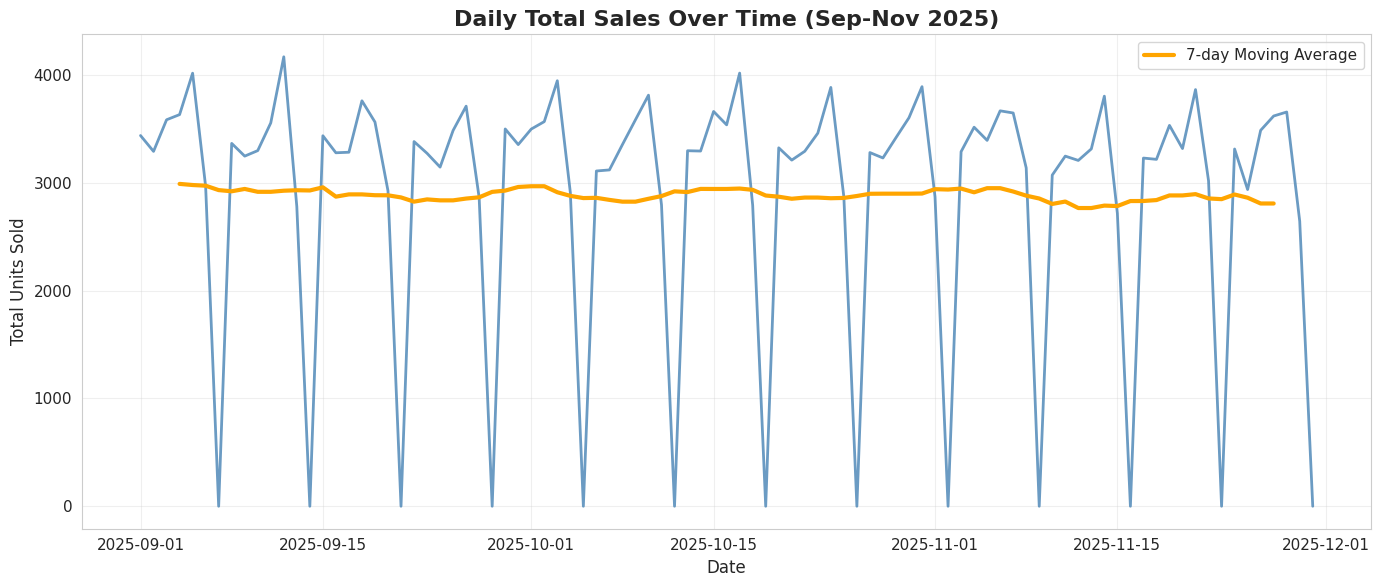

TREND ANALYSIS:
Average daily sales: 2887.4 units
Minimum daily sales: 0 units on 2025-09-07
Maximum daily sales: 4168 units on 2025-09-12
Std deviation: 1223.5 (variability in daily sales)

Trend: DECREASING by ~3.3 units per day


In [ ]:
# Aggregate total sales by date
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()

# Create figure with better size
plt.figure(figsize=(14, 6))

# Plot daily sales
plt.plot(daily_sales['date'], daily_sales['units_sold'],
         linewidth=2, color='steelblue', alpha=0.8)

# Add rolling average to smooth out noise
rolling_avg = daily_sales['units_sold'].rolling(window=7, center=True).mean()
plt.plot(daily_sales['date'], rolling_avg,
         linewidth=3, color='orange', label='7-day Moving Average')

plt.title('Daily Total Sales Over Time (Sep-Nov 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate statistics
print("TREND ANALYSIS:")
print("="*60)
print(f"Average daily sales: {daily_sales['units_sold'].mean():.1f} units")
print(f"Minimum daily sales: {daily_sales['units_sold'].min():.0f} units on {daily_sales.loc[daily_sales['units_sold'].idxmin(), 'date'].date()}")
print(f"Maximum daily sales: {daily_sales['units_sold'].max():.0f} units on {daily_sales.loc[daily_sales['units_sold'].idxmax(), 'date'].date()}")
print(f"Std deviation: {daily_sales['units_sold'].std():.1f} (variability in daily sales)")

# Calculate trend
from scipy import stats
x = np.arange(len(daily_sales))
y = daily_sales['units_sold'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

if slope > 0:
    print(f"\nTrend: INCREASING by ~{slope:.1f} units per day")
elif slope < 0:
    print(f"\nTrend: DECREASING by ~{abs(slope):.1f} units per day")
else:
    print(f"\nTrend: STABLE (no significant trend)")

In [ ]:
# Checking the specific day sale
print(df[df['date'] == '2025-09-07']['units_sold'].sum())

# If it's truly zero
#  Remove that day
df = df[df['date'] != '2025-09-07']



0


### 3.2 Weekly Seasonality - Day of Week Analysis

**Purpose**: Do sales differ between weekdays and weekends?

**Why it matters**:
- Retail often sees weekend peaks
- Informs staffing and inventory decisions
- Important feature for modeling

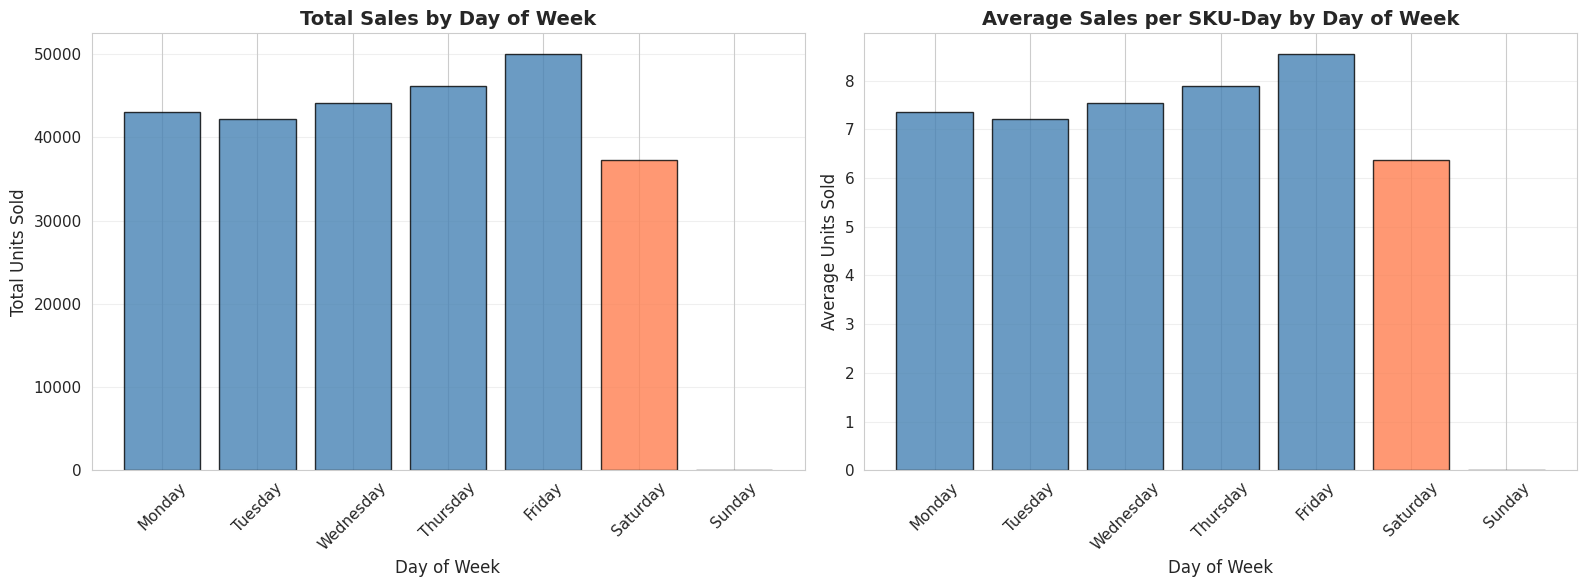

WEEKLY PATTERN ANALYSIS:
Average sales on weekdays: 7.71 units per SKU-day
Average sales on weekends: 3.31 units per SKU-day
Difference: -57.0% (weekdays are busier)

 Best day for sales: Friday
 Worst day for sales: Sunday


In [ ]:
# Aggregate sales by day of week
day_sales = df.groupby('day_name')['units_sold'].agg(['sum', 'mean', 'count']).reset_index()

# Order by day of week (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales['day_name'] = pd.Categorical(day_sales['day_name'], categories=day_order, ordered=True)
day_sales = day_sales.sort_values('day_name')

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total sales by day
axes[0].bar(day_sales['day_name'], day_sales['sum'],
            color=['steelblue']*5 + ['coral', 'coral'],  # Highlight weekends
            alpha=0.8, edgecolor='black')
axes[0].set_title('Total Sales by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Total Units Sold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Average sales per transaction by day
axes[1].bar(day_sales['day_name'], day_sales['mean'],
            color=['steelblue']*5 + ['coral', 'coral'],
            alpha=0.8, edgecolor='black')
axes[1].set_title('Average Sales per SKU-Day by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Average Units Sold', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
weekday_sales = df[df['is_weekend'] == 0]['units_sold'].mean()
weekend_sales = df[df['is_weekend'] == 1]['units_sold'].mean()
difference_pct = ((weekend_sales - weekday_sales) / weekday_sales) * 100

print("WEEKLY PATTERN ANALYSIS:")
print("="*60)
print(f"Average sales on weekdays: {weekday_sales:.2f} units per SKU-day")
print(f"Average sales on weekends: {weekend_sales:.2f} units per SKU-day")
print(f"Difference: {difference_pct:+.1f}% {'(weekends are busier)' if difference_pct > 0 else '(weekdays are busier)'}")

# Find best and worst days
best_day = day_sales.loc[day_sales['mean'].idxmax(), 'day_name']
worst_day = day_sales.loc[day_sales['mean'].idxmin(), 'day_name']
print(f"\n Best day for sales: {best_day}")
print(f" Worst day for sales: {worst_day}")

### 3.3 Promotion Impact Analysis

**Purpose**: How much do promotions boost sales?

**Why it matters**:
- Quantifies promotion effectiveness
- Helps with pricing strategy
- Important predictor for our model

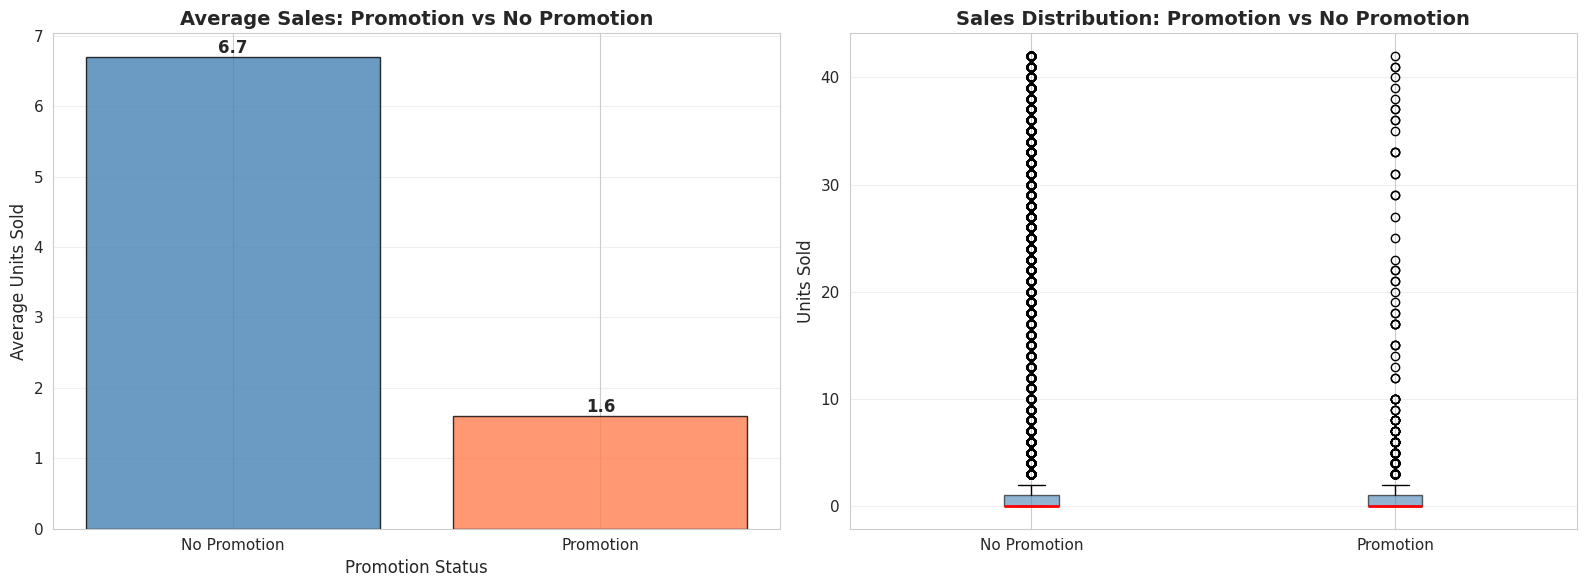

 PROMOTION IMPACT ANALYSIS:
Percentage of records with promotions: 4.1%

Average sales WITHOUT promotion: 6.70 units
Average sales WITH promotion: 1.59 units

Promotion lift: -76.2%
   -> Promotions increase sales by -76.2% on average!

Promotion depth statistics:
  -> Average discount: 22.1%
  -> Max discount: 40.0%


In [ ]:
# Compare sales with and without promotions
promo_comparison = df.groupby('promo_flag')['units_sold'].agg(['mean', 'median', 'count']).reset_index()
promo_comparison['promo_flag'] = promo_comparison['promo_flag'].map({0: 'No Promotion', 1: 'Promotion'})

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average sales comparison
axes[0].bar(promo_comparison['promo_flag'], promo_comparison['mean'],
            color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
axes[0].set_title('Average Sales: Promotion vs No Promotion', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Promotion Status', fontsize=12)
axes[0].set_ylabel('Average Units Sold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, row in promo_comparison.iterrows():
    axes[0].text(i, row['mean'], f"{row['mean']:.1f}",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Distribution comparison (boxplot)
df_boxplot = df[df['units_sold'] < df['units_sold'].quantile(0.95)]  # Remove extreme outliers for better viz
axes[1].boxplot([df_boxplot[df_boxplot['promo_flag']==0]['units_sold'],
                 df_boxplot[df_boxplot['promo_flag']==1]['units_sold']],
                labels=['No Promotion', 'Promotion'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Sales Distribution: Promotion vs No Promotion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Units Sold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis
no_promo_avg = df[df['promo_flag'] == 0]['units_sold'].mean()
promo_avg = df[df['promo_flag'] == 1]['units_sold'].mean()
lift = ((promo_avg - no_promo_avg) / no_promo_avg) * 100

promo_pct = (df['promo_flag'].sum() / len(df)) * 100

print(" PROMOTION IMPACT ANALYSIS:")
print("="*60)
print(f"Percentage of records with promotions: {promo_pct:.1f}%")
print(f"\nAverage sales WITHOUT promotion: {no_promo_avg:.2f} units")
print(f"Average sales WITH promotion: {promo_avg:.2f} units")
print(f"\nPromotion lift: {lift:+.1f}%")
print(f"   -> Promotions increase sales by {lift:.1f}% on average!")

# Analyze by promotion depth
if df['promo_depth'].max() > 0:
    promo_data = df[df['promo_flag'] == 1].copy()
    print(f"\nPromotion depth statistics:")
    print(f"  -> Average discount: {promo_data['promo_depth'].mean()*100:.1f}%")
    print(f"  -> Max discount: {promo_data['promo_depth'].max()*100:.1f}%")

In [ ]:
# Check if promoted items are typically low-sellers
promo_items = df[df['promo_flag'] == 1]['sku_id'].unique()
non_promo_items = df[df['promo_flag'] == 0]['sku_id'].unique()

# Compare baseline sales (when not on promo)
baseline_sales = df[df['promo_flag'] == 0].groupby('sku_id')['units_sold'].mean()
print("Average sales for items that get promoted:", baseline_sales[promo_items].mean())
print("Average sales for items that don't get promoted:", baseline_sales[non_promo_items].mean())

Average sales for items that get promoted: 0.9676367150061661
Average sales for items that don't get promoted: 2.9632813375953475


### 3.4 Product Category Analysis

**Purpose**: Which product categories (PHL1) drive most sales?

**Why it matters**:
- Focus on high-volume categories
- Different categories may need different models
- Informs feature engineering strategy

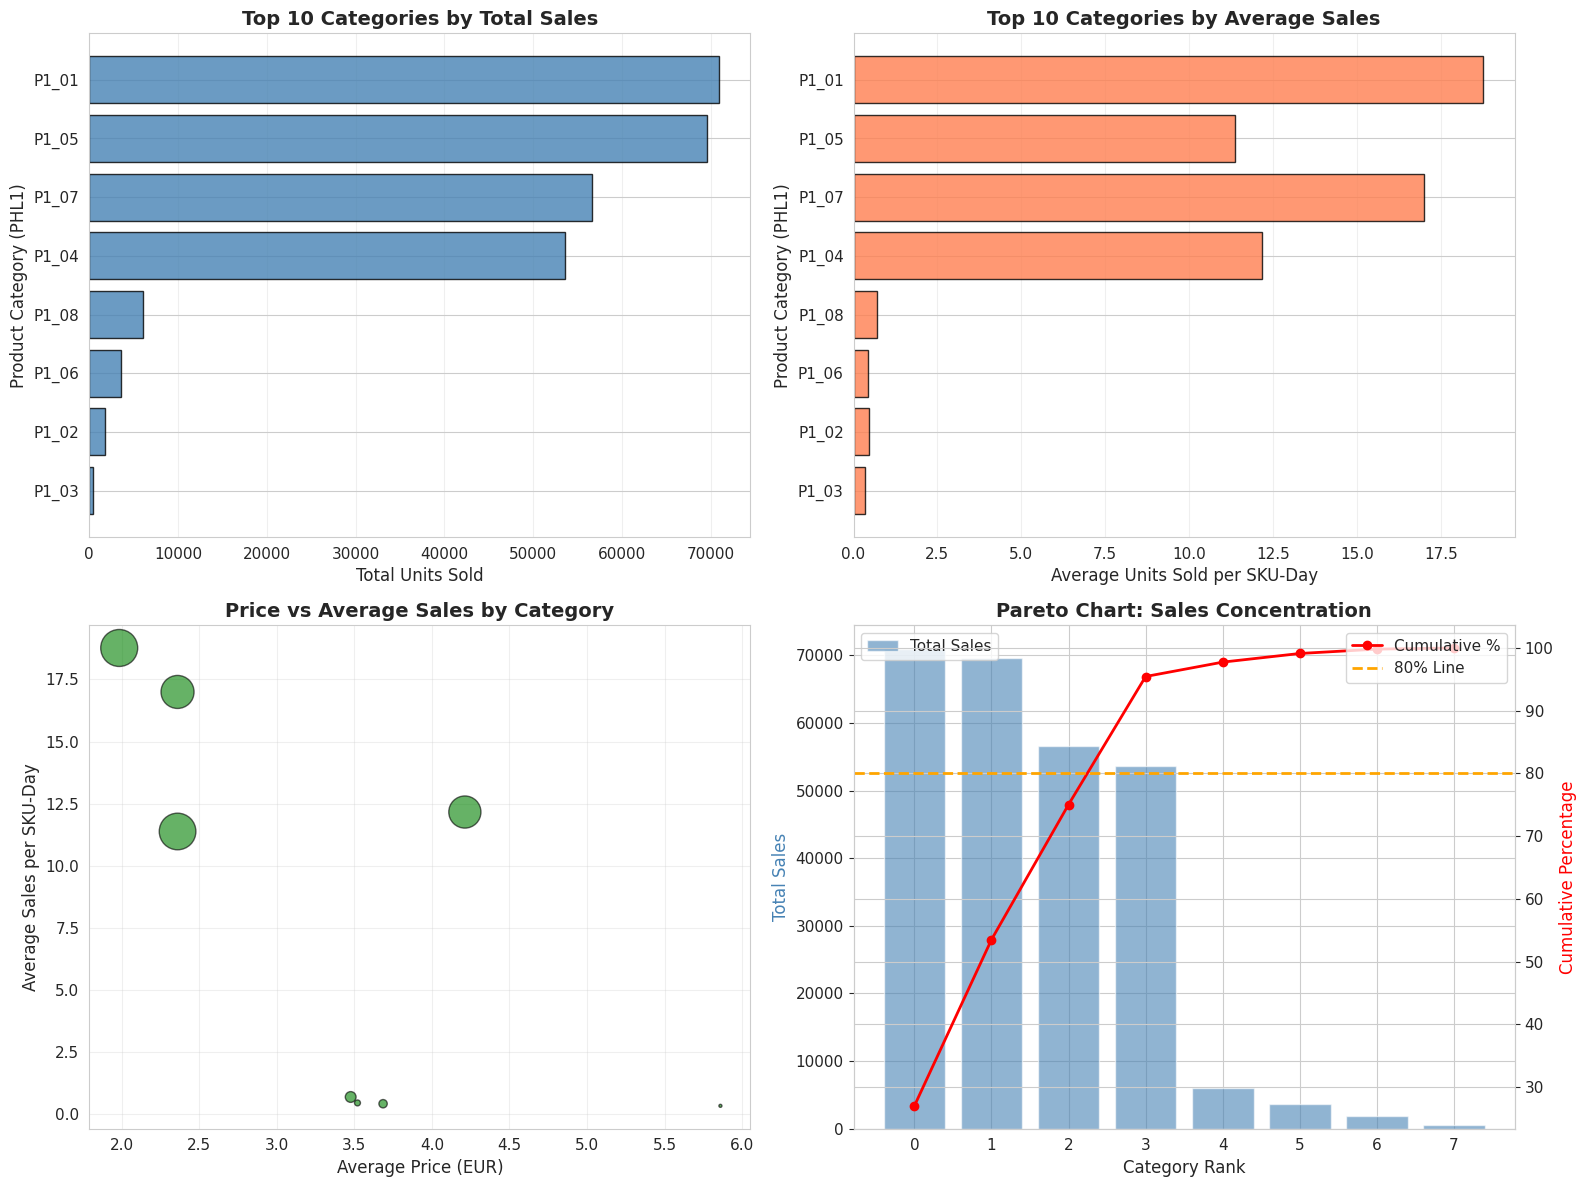

 CATEGORY ANALYSIS:
Number of product categories (PHL1): 8

Top 5 categories by total sales:
  1. P1_01: 70,935 units (3,780 records)
  5. P1_05: 69,637 units (6,120 records)
  7. P1_07: 56,596 units (3,330 records)
  4. P1_04: 53,631 units (4,410 records)
  8. P1_08: 6,025 units (8,730 records)

 Pareto Principle (80/20 rule):
  -> Top 20% of categories (1 categories)
  -> Account for 27.0% of total sales


In [ ]:
# Aggregate sales by product category
category_sales = df.groupby('phl1_id').agg({
    'units_sold': ['sum', 'mean', 'count'],
    'price': 'mean'
}).reset_index()

category_sales.columns = ['phl1_id', 'total_sales', 'avg_sales', 'num_records', 'avg_price']
category_sales = category_sales.sort_values('total_sales', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total sales by category (Top 10)
top_10 = category_sales.head(10)
axes[0, 0].barh(top_10['phl1_id'].astype(str), top_10['total_sales'],
                color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Top 10 Categories by Total Sales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Units Sold', fontsize=12)
axes[0, 0].set_ylabel('Product Category (PHL1)', fontsize=12)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Average sales per transaction by category
axes[0, 1].barh(top_10['phl1_id'].astype(str), top_10['avg_sales'],
                color='coral', alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Top 10 Categories by Average Sales', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Average Units Sold per SKU-Day', fontsize=12)
axes[0, 1].set_ylabel('Product Category (PHL1)', fontsize=12)
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Price vs Sales relationship
axes[1, 0].scatter(category_sales['avg_price'], category_sales['avg_sales'],
                   s=category_sales['total_sales']/100,  # Size by total sales
                   alpha=0.6, color='green', edgecolor='black')
axes[1, 0].set_title('Price vs Average Sales by Category', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Price (EUR)', fontsize=12)
axes[1, 0].set_ylabel('Average Sales per SKU-Day', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Category distribution (Pareto chart)
category_sales_sorted = category_sales.sort_values('total_sales', ascending=False).reset_index(drop=True)
category_sales_sorted['cumulative_pct'] = (category_sales_sorted['total_sales'].cumsum() /
                                             category_sales_sorted['total_sales'].sum() * 100)

ax1 = axes[1, 1]
ax2 = ax1.twinx()

ax1.bar(range(len(category_sales_sorted)), category_sales_sorted['total_sales'],
        color='steelblue', alpha=0.6, label='Total Sales')
ax2.plot(range(len(category_sales_sorted)), category_sales_sorted['cumulative_pct'],
         color='red', marker='o', linewidth=2, label='Cumulative %')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='80% Line')

ax1.set_title('Pareto Chart: Sales Concentration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category Rank', fontsize=12)
ax1.set_ylabel('Total Sales', fontsize=12, color='steelblue')
ax2.set_ylabel('Cumulative Percentage', fontsize=12, color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Summary statistics
print(" CATEGORY ANALYSIS:")
print("="*60)
print(f"Number of product categories (PHL1): {df['phl1_id'].nunique()}")
print(f"\nTop 5 categories by total sales:")
for i, row in category_sales.head(5).iterrows():
    print(f"  {i+1}. {row['phl1_id']}: {row['total_sales']:,.0f} units ({row['num_records']:,} records)")

# Calculate 80/20 rule
top_20_pct_categories = int(len(category_sales) * 0.2)
top_20_sales = category_sales.head(top_20_pct_categories)['total_sales'].sum()
total_sales = category_sales['total_sales'].sum()
concentration = (top_20_sales / total_sales) * 100

print(f"\n Pareto Principle (80/20 rule):")
print(f"  -> Top 20% of categories ({top_20_pct_categories} categories)")
print(f"  -> Account for {concentration:.1f}% of total sales")

### 3.5 Sales Distribution and Outliers

**Purpose**: Understand the distribution of our target variable (units_sold)

**Why it matters**:
- Identifies outliers (very high/low sales)
- Shows if data is skewed
- Informs modeling choices (e.g., log transformation needed?)

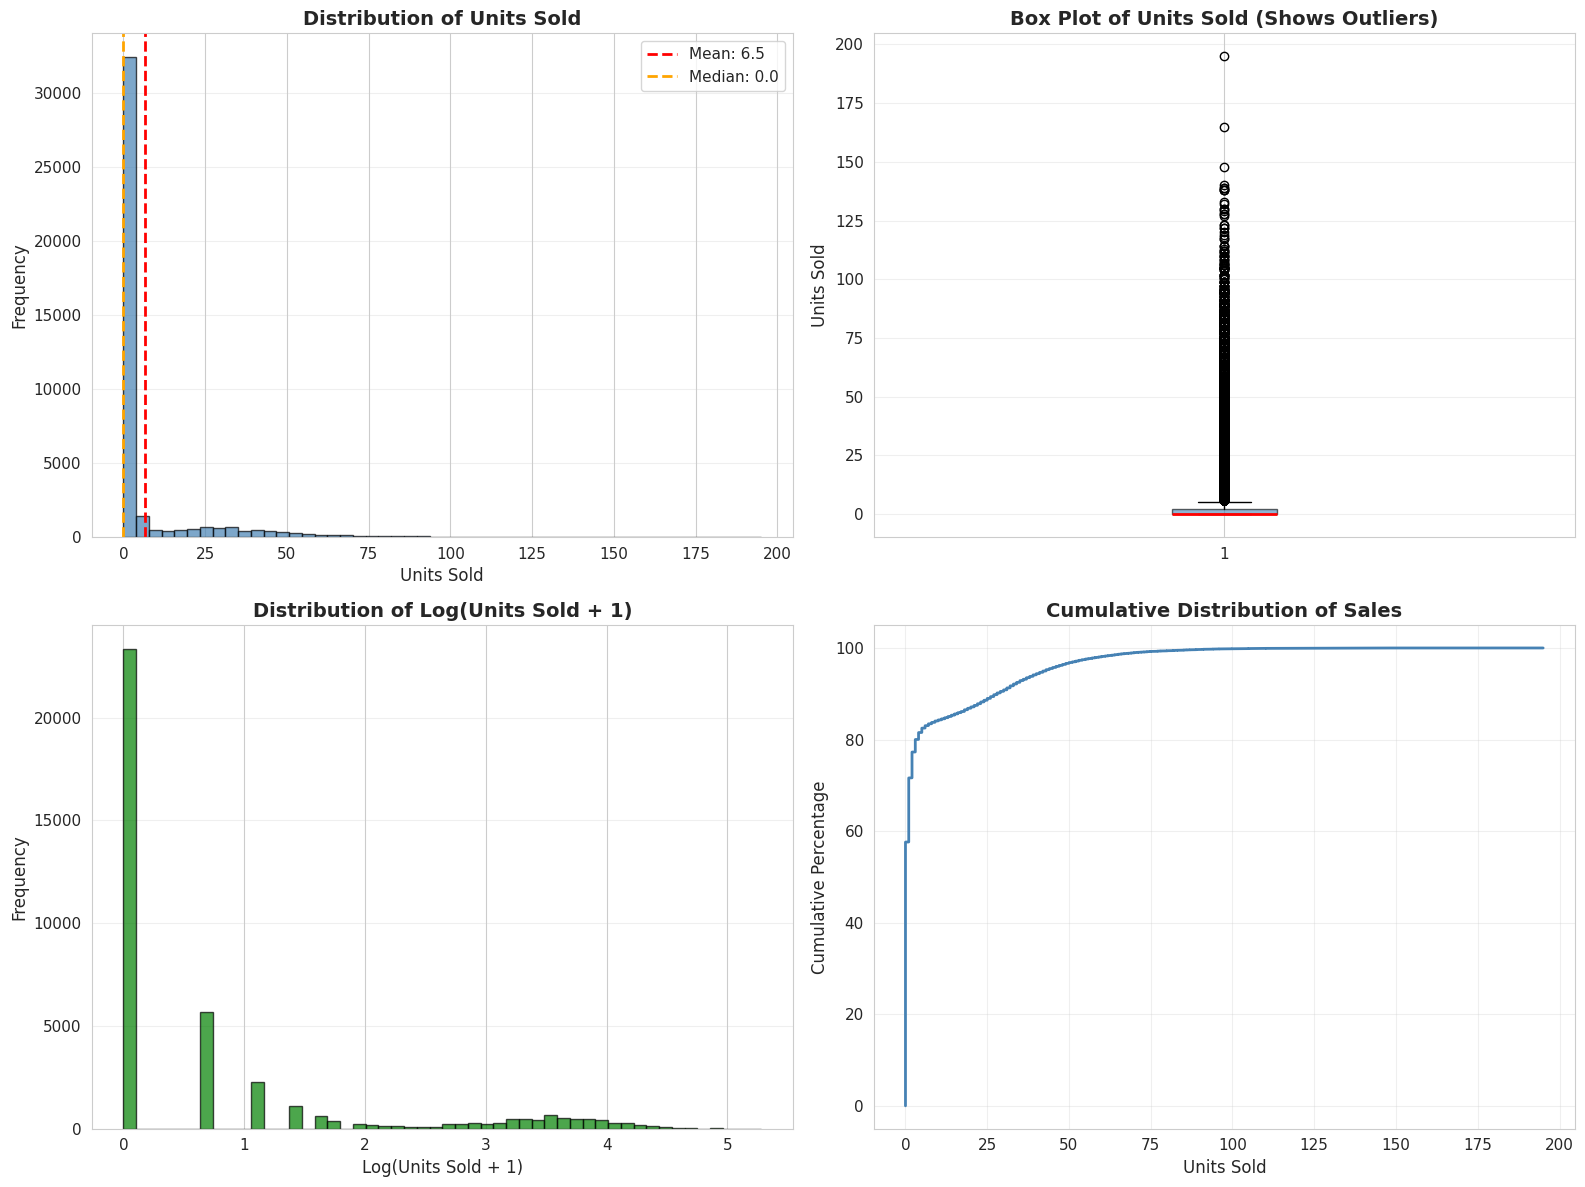

 DISTRIBUTION ANALYSIS:
Mean: 6.49 units
Median: 0.00 units
Mode: 0 units (most common value)
Std deviation: 15.57

Range:
  -> Minimum: 0 units
  -> Maximum: 195 units

Percentiles:
  • 25th percentile: 0.0 units
  • 50th percentile: 0.0 units
  • 75th percentile: 2.0 units
  • 90th percentile: 28.0 units
  • 95th percentile: 43.0 units
  • 99th percentile: 71.0 units

 OUTLIER DETECTION:
Outlier threshold (Q3 + 1.5*IQR): 5.0 units
Number of outliers: 7,092 (17.51% of data)
These are products with unusually high sales

 Skewness: 3.14
  -> Highly right-skewed (long tail of high values)
  -> Consider log transformation for modeling


In [ ]:
# Create comprehensive distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram of sales
axes[0, 0].hist(df['units_sold'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['units_sold'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['units_sold'].mean():.1f}")
axes[0, 0].axvline(df['units_sold'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['units_sold'].median():.1f}")
axes[0, 0].set_title('Distribution of Units Sold', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Units Sold', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Box plot to show outliers
axes[0, 1].boxplot(df['units_sold'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Box Plot of Units Sold (Shows Outliers)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Units Sold', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Log-scale histogram (to see distribution better)
# Add 1 to avoid log(0)
axes[1, 0].hist(np.log1p(df['units_sold']), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Log(Units Sold + 1)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Log(Units Sold + 1)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Cumulative distribution
sorted_sales = np.sort(df['units_sold'])
cumulative = np.arange(1, len(sorted_sales) + 1) / len(sorted_sales) * 100
axes[1, 1].plot(sorted_sales, cumulative, linewidth=2, color='steelblue')
axes[1, 1].set_title('Cumulative Distribution of Sales', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Units Sold', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Percentage', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis
print(" DISTRIBUTION ANALYSIS:")
print("="*60)
print(f"Mean: {df['units_sold'].mean():.2f} units")
print(f"Median: {df['units_sold'].median():.2f} units")
print(f"Mode: {df['units_sold'].mode()[0]:.0f} units (most common value)")
print(f"Std deviation: {df['units_sold'].std():.2f}")
print(f"\nRange:")
print(f"  -> Minimum: {df['units_sold'].min():.0f} units")
print(f"  -> Maximum: {df['units_sold'].max():.0f} units")

# Percentiles
print(f"\nPercentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    value = df['units_sold'].quantile(p/100)
    print(f"  • {p}th percentile: {value:.1f} units")

# Identify outliers using IQR method
Q1 = df['units_sold'].quantile(0.25)
Q3 = df['units_sold'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = df[df['units_sold'] > outlier_threshold]

print(f"\n OUTLIER DETECTION:")
print(f"Outlier threshold (Q3 + 1.5*IQR): {outlier_threshold:.1f} units")
print(f"Number of outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}% of data)")
print(f"These are products with unusually high sales")

# Skewness
from scipy.stats import skew
skewness = skew(df['units_sold'])
print(f"\n Skewness: {skewness:.2f}")
if skewness > 1:
    print("  -> Highly right-skewed (long tail of high values)")
    print("  -> Consider log transformation for modeling")
elif skewness > 0.5:
    print("  -> Moderately right-skewed")
else:
    print("  -> Relatively symmetric distribution")

### 3.6 Correlation Analysis

**Purpose**: Which features are related to sales?

**Why it matters**:
- Identifies important predictors
- Reveals multicollinearity (features correlated with each other)
- Guides feature selection for modeling

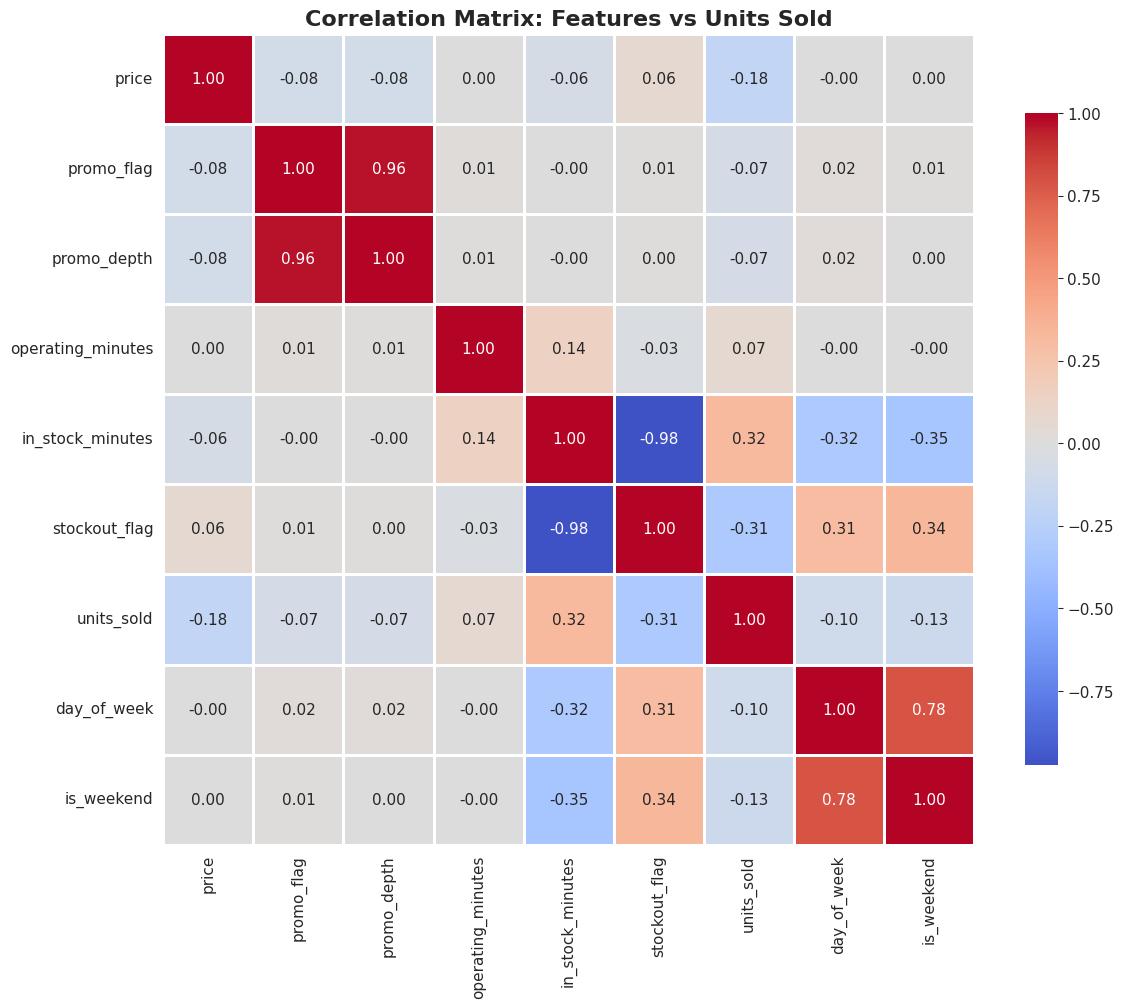

 CORRELATION WITH UNITS_SOLD (Target Variable):

Positive correlations (↑ feature → ↑ sales):
 ->  in_stock_minutes         : +0.319

Negative correlations (↑ feature → ↓ sales):
  -> is_weekend               : -0.126
  -> price                    : -0.185
  -> stockout_flag            : -0.313

 INTERPRETATION:
  -> |correlation| > 0.7: Very strong relationship
  -> |correlation| > 0.4: Moderate relationship
  -> |correlation| > 0.2: Weak but notable relationship
  -> |correlation| < 0.1: Negligible relationship

 KEY INSIGHTS FOR MODELING:
Top 3 features correlated with sales:
  1. in_stock_minutes: +0.319
  2. stockout_flag: -0.313
  3. price: -0.185


In [ ]:
# Select numerical features for correlation analysis
numerical_features = ['price', 'promo_flag', 'promo_depth', 'operating_minutes',
                      'in_stock_minutes', 'stockout_flag', 'units_sold',
                      'day_of_week', 'is_weekend']

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Features vs Units Sold', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Analyze correlations with target variable
target_correlations = correlation_matrix['units_sold'].sort_values(ascending=False)

print(" CORRELATION WITH UNITS_SOLD (Target Variable):")
print("="*60)
print("\nPositive correlations (↑ feature → ↑ sales):")
positive_corr = target_correlations[target_correlations > 0.1]
for feature, corr in positive_corr.items():
    if feature != 'units_sold':
        print(f" ->  {feature:25s}: {corr:+.3f}")

print("\nNegative correlations (↑ feature → ↓ sales):")
negative_corr = target_correlations[target_correlations < -0.1]
for feature, corr in negative_corr.items():
    print(f"  -> {feature:25s}: {corr:+.3f}")

print("\n INTERPRETATION:")
print("  -> |correlation| > 0.7: Very strong relationship")
print("  -> |correlation| > 0.4: Moderate relationship")
print("  -> |correlation| > 0.2: Weak but notable relationship")
print("  -> |correlation| < 0.1: Negligible relationship")

# Feature importance hints
print("\n KEY INSIGHTS FOR MODELING:")
strongest = target_correlations.drop('units_sold').abs().sort_values(ascending=False).head(3)
print("Top 3 features correlated with sales:")
for i, (feature, corr) in enumerate(strongest.items(), 1):
    print(f"  {i}. {feature}: {target_correlations[feature]:+.3f}")

---
## 4. Feature Engineering <a id='features'></a>

### Purpose:
Transform raw data into meaningful features that help the model learn patterns.

### Why Feature Engineering Matters:
- **Raw data isn't enough**: Models need curated signals
- **Domain knowledge**: Use what we learned in EDA
- **Performance boost**: Good features = better predictions

### Features i'll Create:
1. **Lag features**: Historical sales (yesterday, last week)
2. **Rolling statistics**: Moving averages (7-day, 14-day)
3. **Product metrics**: Popularity, price positioning
4. **Venue metrics**: Store characteristics
5. **Temporal features**: Already created (day_of_week, etc.)

### Critical Rule - Avoiding Data Leakage:
 **WIll avoid to use data from the future or the outcome itself**
 **Only will use what would be available at prediction time i.e., best approach**

**Example:**
-  BAD: Use `in_stock_minutes` (only know after day ends)
-  GOOD: Use `operating_minutes` (know in advance)
-  GOOD: Use sales from previous days (historical)

In [ ]:
# CRITICAL: Sort data by date for time series features
# Lag features only work if data is in chronological order!

print(" Sorting data by date and SKU...")
df = df.sort_values(['sku_id', 'venue_id', 'date']).reset_index(drop=True)

print(" Data sorted!")
print("\nFirst few rows (should be sequential dates for same SKU):")
print(df[['date', 'venue_id', 'sku_id', 'units_sold']].head(10))

print("\n Why sorting matters:")
print("  -> Lag features need chronological order")
print("  -> 'Yesterday's sales' only makes sense if yesterday comes before today")
print("  -> Wrong order = wrong features = bad model!")

 Sorting data by date and SKU...
 Data sorted!

First few rows (should be sequential dates for same SKU):
        date venue_id sku_id  units_sold
0 2025-09-01     V001  S0001          67
1 2025-09-02     V001  S0001          16
2 2025-09-03     V001  S0001          28
3 2025-09-04     V001  S0001          43
4 2025-09-05     V001  S0001          15
5 2025-09-06     V001  S0001          25
6 2025-09-08     V001  S0001          46
7 2025-09-09     V001  S0001          38
8 2025-09-10     V001  S0001          12
9 2025-09-11     V001  S0001          26

 Why sorting matters:
  -> Lag features need chronological order
  -> 'Yesterday's sales' only makes sense if yesterday comes before today
  -> Wrong order = wrong features = bad model!


### 4.1 Lag Features - Historical Sales

**Concept**: Use past sales to predict future sales

**Logic**:
- If product sold 50 units yesterday -> likely to sell similar amount today
- If product sold 100 units last Monday -> similar pattern next Monday

**Features to create**:
- `sales_lag_1`: Sales 1 day ago (yesterday)
- `sales_lag_7`: Sales 7 days ago (same day last week)
- `sales_lag_14`: Sales 14 days ago (two weeks back)

**Why different lags?**
- Lag 1: Captures immediate trends
- Lag 7: Captures weekly cycles (Monday → Monday)
- Lag 14: Captures longer patterns

In [ ]:
# Create lag features - sales from previous time periods
print(" Creating lag features...")

# Group by SKU and venue (each product at each store separately)
# Within each group, shift sales by 1, 7, and 14 days

df['sales_lag_1'] = df.groupby(['sku_id', 'venue_id'])['units_sold'].shift(1)
df['sales_lag_7'] = df.groupby(['sku_id', 'venue_id'])['units_sold'].shift(7)
df['sales_lag_14'] = df.groupby(['sku_id', 'venue_id'])['units_sold'].shift(14)

print(" Lag features created!")

# Check for missing values (first days won't have lags)
print("\nMissing values in lag features:")
print(f"  -> sales_lag_1: {df['sales_lag_1'].isna().sum():,} ({df['sales_lag_1'].isna().sum()/len(df)*100:.1f}%)")
print(f"  -> sales_lag_7: {df['sales_lag_7'].isna().sum():,} ({df['sales_lag_7'].isna().sum()/len(df)*100:.1f}%)")
print(f"  -> sales_lag_14: {df['sales_lag_14'].isna().sum():,} ({df['sales_lag_14'].isna().sum()/len(df)*100:.1f}%)")

print("\n Why missing values?")
print("  -> First day has no 'yesterday' -> lag_1 is NaN")
print("  -> First week has no 'last week' -> lag_7 is NaN")
print("  -> We'll handle these later (fill with 0 or drop)")

# Example: Show lag features for one product
example_sku = df['sku_id'].iloc[0]
example_venue = df['venue_id'].iloc[0]
example_data = df[(df['sku_id'] == example_sku) & (df['venue_id'] == example_venue)].head(15)

print(f"\nExample: SKU {example_sku} at venue {example_venue}")
print(example_data[['date', 'units_sold', 'sales_lag_1', 'sales_lag_7']].to_string(index=False))

 Creating lag features...
 Lag features created!

Missing values in lag features:
  -> sales_lag_1: 450 (1.1%)
  -> sales_lag_7: 3,150 (7.8%)
  -> sales_lag_14: 6,300 (15.6%)

 Why missing values?
  -> First day has no 'yesterday' -> lag_1 is NaN
  -> First week has no 'last week' -> lag_7 is NaN
  -> We'll handle these later (fill with 0 or drop)

Example: SKU S0001 at venue V001
      date  units_sold  sales_lag_1  sales_lag_7
2025-09-01          67          NaN          NaN
2025-09-02          16        67.00          NaN
2025-09-03          28        16.00          NaN
2025-09-04          43        28.00          NaN
2025-09-05          15        43.00          NaN
2025-09-06          25        15.00          NaN
2025-09-08          46        25.00          NaN
2025-09-09          38        46.00        67.00
2025-09-10          12        38.00        16.00
2025-09-11          26        12.00        28.00
2025-09-12          61        26.00        43.00
2025-09-13          36      

### 4.2 Rolling Statistics - Moving Averages

**Concept**: Smooth out noise by averaging recent sales

**Why use rolling averages?**
- Single day might be unusual (stockout, promotion, etc.)
- Average over 7 days = more stable signal
- Captures recent trend without day-to-day noise

**Features to create**:
- `rolling_mean_7`: Average sales over last 7 days
- `rolling_mean_14`: Average sales over last 14 days
- `rolling_std_7`: Variability in last 7 days (is demand stable?)

In [ ]:
# Create rolling statistics - averages over recent time windows
print(" Creating rolling statistics...")

# Rolling mean (average sales over last N days)
df['rolling_mean_7'] = df.groupby(['sku_id', 'venue_id'])['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

df['rolling_mean_14'] = df.groupby(['sku_id', 'venue_id'])['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=14, min_periods=1).mean()
)

# Rolling standard deviation (measure of variability)
df['rolling_std_7'] = df.groupby(['sku_id', 'venue_id'])['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).std()
)

# Fill NaN in rolling_std with 0
df['rolling_std_7'] = df['rolling_std_7'].fillna(0)

print(" Rolling features created!")

print("\nExample values:")
print(f"  -> rolling_mean_7 range: {df['rolling_mean_7'].min():.2f} to {df['rolling_mean_7'].max():.2f}")
print(f"  -> rolling_mean_14 range: {df['rolling_mean_14'].min():.2f} to {df['rolling_mean_14'].max():.2f}")
print(f"  -> rolling_std_7 range: {df['rolling_std_7'].min():.2f} to {df['rolling_std_7'].max():.2f}")

print("\n Key points:")
print("  -> Used .shift(1) to avoid leakage (don't include today in average)")
print("  -> min_periods=1 means calculate even with <7 days (for early days)")
print("  -> Higher std = more variable demand (harder to predict)")

 Creating rolling statistics...
 Rolling features created!

Example values:
  -> rolling_mean_7 range: 0.00 to 129.00
  -> rolling_mean_14 range: 0.00 to 129.00
  -> rolling_std_7 range: 0.00 to 62.70

 Key points:
  -> Used .shift(1) to avoid leakage (don't include today in average)
  -> min_periods=1 means calculate even with <7 days (for early days)
  -> Higher std = more variable demand (harder to predict)


### 4.3 Product-Level Features

**Concept**: Characteristics of each SKU

**Features to create**:
- `product_avg_sales`: How popular is this SKU overall?
- `product_price_vs_category`: Is this SKU expensive for its category?
- `days_since_launch`: How long has SKU been selling?

**Why these help**:
- Popular products sell consistently
- Price positioning affects demand
- New products behave differently than established ones

In [ ]:
# Create product-level aggregated features
print(" Creating product-level features...")

# Average sales per SKU across all time and venues
product_stats = df.groupby('sku_id').agg({
    'units_sold': ['mean', 'std', 'sum'],
    'price': 'mean',
    'date': 'min'  # First date SKU appears
}).reset_index()

product_stats.columns = ['sku_id', 'product_avg_sales', 'product_std_sales',
                          'product_total_sales', 'product_avg_price', 'product_first_date']

# Merge back to main dataframe
df = df.merge(product_stats, on='sku_id', how='left')

# Calculate days since product launch
df['days_since_launch'] = (df['date'] - df['product_first_date']).dt.days

# Price ratio vs category average
category_avg_price = df.groupby('phl1_id')['price'].mean().reset_index()
category_avg_price.columns = ['phl1_id', 'category_avg_price']
df = df.merge(category_avg_price, on='phl1_id', how='left')

df['price_vs_category'] = df['price'] / df['category_avg_price']

# Clean up temporary columns
df = df.drop(['product_first_date', 'category_avg_price'], axis=1)

print(" Product features created!")

print("\nNew features summary:")
print(f"  -> product_avg_sales: Mean={df['product_avg_sales'].mean():.2f}, Range=[{df['product_avg_sales'].min():.2f}, {df['product_avg_sales'].max():.2f}]")
print(f"  -> days_since_launch: Mean={df['days_since_launch'].mean():.1f} days, Max={df['days_since_launch'].max()} days")
print(f"  -> price_vs_category: Mean={df['price_vs_category'].mean():.2f} (1.0 = at category average)")

print("\n Interpretation:")
print("  -> product_avg_sales: High = popular SKU → predict higher sales")
print("  -> days_since_launch: New products (low value) might have unstable demand")
print("  -> price_vs_category > 1.5: Premium product → potentially lower volume")

 Creating product-level features...
 Product features created!

New features summary:
  -> product_avg_sales: Mean=6.49, Range=[0.00, 43.09]
  -> days_since_launch: Mean=45.4 days, Max=90 days
  -> price_vs_category: Mean=1.00 (1.0 = at category average)

 Interpretation:
  -> product_avg_sales: High = popular SKU → predict higher sales
  -> days_since_launch: New products (low value) might have unstable demand
  -> price_vs_category > 1.5: Premium product → potentially lower volume


### 4.4 Venue-Level Features

**Concept**: Characteristics of each store

**Features to create**:
- `venue_avg_sales`: How busy is this store overall?
- `venue_sku_count`: How many SKUs does venue carry?
- `venue_avg_operating_hours`: Typical store hours

**Why these help**:
- High-volume stores sell more of everything
- Larger selection = different dynamics
- Operating hours affect sales opportunity

In [ ]:
# Create venue-level aggregated features
print(" Creating venue-level features...")

# Aggregate statistics per venue
venue_stats = df.groupby('venue_id').agg({
    'units_sold': 'mean',
    'sku_id': 'nunique',
    'operating_minutes': 'mean'
}).reset_index()

venue_stats.columns = ['venue_id', 'venue_avg_sales', 'venue_sku_count', 'venue_avg_operating_hours']

# Merge back to main dataframe
df = df.merge(venue_stats, on='venue_id', how='left')

print(" Venue features created!")

print("\nVenue statistics:")
print(venue_stats.to_string(index=False))

print("\n Insights:")
for idx, row in venue_stats.iterrows():
    print(f"  -> {row['venue_id']}: Avg {row['venue_avg_sales']:.1f} units/day, {row['venue_sku_count']} SKUs, {row['venue_avg_operating_hours']:.0f} min open")

 Creating venue-level features...
 Venue features created!

Venue statistics:
venue_id  venue_avg_sales  venue_sku_count  venue_avg_operating_hours
    V001             5.22               90                     900.00
    V002             4.54               90                     720.00
    V003             6.37               90                     900.00
    V004            10.20               90                     900.00
    V005             6.10               90                     840.00

 Insights:
  -> V001: Avg 5.2 units/day, 90 SKUs, 900 min open
  -> V002: Avg 4.5 units/day, 90 SKUs, 720 min open
  -> V003: Avg 6.4 units/day, 90 SKUs, 900 min open
  -> V004: Avg 10.2 units/day, 90 SKUs, 900 min open
  -> V005: Avg 6.1 units/day, 90 SKUs, 840 min open


### 4.5 Categorical Feature Encoding

**Problem**: ML models need numbers, not text

**Columns to encode**:
- `phl1_id`, `phl2_id`, `phl3_id` (product categories)
- `venue_id` (store identifier)
- `sku_id` (product identifier)

**Encoding Strategy**:
- **Label Encoding**: Convert categories to numbers (0, 1, 2, ...)
- **Why not One-Hot?**: Too many unique SKUs (235) would create 235 columns!
- **XGBoost handles this**: Tree-based models work well with label encoding

In [ ]:
# Encode categorical variables as numbers
print(" Encoding categorical features...")

from sklearn.preprocessing import LabelEncoder

# List of categorical columns to encode
categorical_columns = ['venue_id', 'sku_id', 'phl1_id', 'phl2_id', 'phl3_id']

# Create label encoders and transform
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

    print(f"   {col}: {df[col].nunique()} categories → encoded as 0-{df[col].nunique()-1}")

print("\n All categorical features encoded!")

print("\nExample: First SKU encoding")
example = df[['sku_id', 'sku_id_encoded']].drop_duplicates().head()
print(example.to_string(index=False))

print("\n Note:")
print("  -> Original columns kept for reference")
print("  -> '_encoded' columns will be used in model")
print("  -> Label encoders saved (needed for future predictions)")

 Encoding categorical features...
   venue_id: 5 categories → encoded as 0-4
   sku_id: 235 categories → encoded as 0-234
   phl1_id: 8 categories → encoded as 0-7
   phl2_id: 24 categories → encoded as 0-23
   phl3_id: 61 categories → encoded as 0-60

 All categorical features encoded!

Example: First SKU encoding
sku_id  sku_id_encoded
 S0001               0
 S0002               1
 S0003               2
 S0004               3
 S0005               4

 Note:
  -> Original columns kept for reference
  -> '_encoded' columns will be used in model
  -> Label encoders saved (needed for future predictions)


In [ ]:
# Handle missing values in lag features
print(" Handling missing values in lag features...")

print("\nMissing values before filling:")
lag_cols = ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'rolling_mean_7', 'rolling_mean_14']
for col in lag_cols:
    missing = df[col].isna().sum()
    print(f"  -> {col}: {missing:,} missing ({missing/len(df)*100:.1f}%)")

# Fill missing lag values with 0
# Reasoning: If no history, assume no sales (conservative estimate)
df[lag_cols] = df[lag_cols].fillna(0)

print("\n Missing values filled with 0")

print("\nRationale:")
print("  -> Early days have no history → assume 0 (safe default)")
print("  -> Alternative: Could use overall mean, but 0 is more conservative")
print("  -> Model will learn that 0 lag + other features = prediction")

# Verify no missing values remain
print("\nFinal missing value check:")
print(f"Total missing values: {df.isnull().sum().sum()}")

 Handling missing values in lag features...

Missing values before filling:
  -> sales_lag_1: 450 missing (1.1%)
  -> sales_lag_7: 3,150 missing (7.8%)
  -> sales_lag_14: 6,300 missing (15.6%)
  -> rolling_mean_7: 450 missing (1.1%)
  -> rolling_mean_14: 450 missing (1.1%)

 Missing values filled with 0

Rationale:
  -> Early days have no history → assume 0 (safe default)
  -> Alternative: Could use overall mean, but 0 is more conservative
  -> Model will learn that 0 lag + other features = prediction

Final missing value check:
Total missing values: 0


### 4.6 Final Feature Selection

**Features We'll Use for Modeling:**

####  **Temporal Features** (5)
- `day_of_week`, `is_weekend`, `week_of_year`, `month`

####  **Lag Features** (3)
- `sales_lag_1`, `sales_lag_7`, `sales_lag_14`

####  **Rolling Features** (3)
- `rolling_mean_7`, `rolling_mean_14`, `rolling_std_7`

####  **Product Features** (4)
- `product_avg_sales`, `product_std_sales`, `days_since_launch`, `price_vs_category`

####  **Venue Features** (3)
- `venue_avg_sales`, `venue_sku_count`, `venue_avg_operating_hours`

####  **Categorical Features** (5)
- `venue_id_encoded`, `sku_id_encoded`, `phl1_id_encoded`, `phl2_id_encoded`, `phl3_id_encoded`

####  **Price & Promotion** (3)
- `price`, `promo_flag`, `promo_depth`

####  **Operations** (1)
- `operating_minutes`

**Total: 27 features**

---

####  **Features We're NOT Using** (Data Leakage!)
- `in_stock_minutes` - Only known after day ends
- `stockout_flag` - Outcome of sales, not predictor
- `country_id` - All same value (no variation)

In [ ]:
# Define final feature list for modeling
print(" Finalizing feature set...")

# All features that will be used
feature_columns = [
    # Temporal
    'day_of_week', 'is_weekend', 'week_of_year', 'month',

    # Lags
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14',

    # Rolling stats
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',

    # Product features
    'product_avg_sales', 'product_std_sales', 'days_since_launch', 'price_vs_category',

    # Venue features
    'venue_avg_sales', 'venue_sku_count', 'venue_avg_operating_hours',

    # Categorical (encoded)
    'venue_id_encoded', 'sku_id_encoded',
    'phl1_id_encoded', 'phl2_id_encoded', 'phl3_id_encoded',

    # Price & Promo
    'price', 'promo_flag', 'promo_depth',

    # Operations
    'operating_minutes'
]

target_column = 'units_sold'

print(f" Feature set finalized!")
print(f"\nTotal features: {len(feature_columns)}")
print("\nFeature categories:")
print(f"  -> Temporal: 4")
print(f"  -> Historical (lags + rolling): 6")
print(f"  -> Product characteristics: 4")
print(f"  -> Venue characteristics: 3")
print(f"  -> Categorical identifiers: 5")
print(f"  -> Price & promotions: 3")
print(f"  -> Operational: 1")

# Verify all features exist in dataframe
missing_features = [f for f in feature_columns if f not in df.columns]
if missing_features:
    print(f"\n WARNING: Missing features: {missing_features}")
else:
    print(f"\n All features present in dataframe!")

# Check data types
print("\nFeature data types:")
print(df[feature_columns].dtypes.value_counts())

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE!")
print("="*60)
print(f"Ready for modeling with {len(feature_columns)} features predicting {target_column}")

 Finalizing feature set...
 Feature set finalized!

Total features: 26

Feature categories:
  -> Temporal: 4
  -> Historical (lags + rolling): 6
  -> Product characteristics: 4
  -> Venue characteristics: 3
  -> Categorical identifiers: 5
  -> Price & promotions: 3
  -> Operational: 1

 All features present in dataframe!

Feature data types:
float64    13
int64      10
int32       2
UInt32      1
Name: count, dtype: int64

FEATURE ENGINEERING COMPLETE!
Ready for modeling with 26 features predicting units_sold


---
## 5. Modeling <a id='modeling'></a>

### Purpose:
Train a machine learning model to predict grocery sales

### Why XGBoost?
- **Handles mixed features**: Numerical + categorical without preprocessing
- **Robust to outliers**: Tree-based, not affected by extreme values
- **Handles zeros well**: Our data has 50% zero sales - XGBoost excels here
- **Feature importance**: Shows which features matter most
- **Industry standard**: Proven for tabular data forecasting
- **No distribution assumptions**: Works with skewed data (ours has skewness=3.16)

### Model Architecture:
**Gradient Boosting Decision Trees**
- Builds trees sequentially
- Each tree corrects previous tree's errors
- Final prediction = sum of all trees
- Analogy: Committee of experts, each fixing others' mistakes

### Critical: Time-Based Train/Test Split
 **NEVER** randomly shuffle time series data
 **ALWAYS** use chronological split:
- Train: Earlier dates (first 80%)
- Test: Later dates (last 20%)
- Mimics real deployment (predict future from past)

In [ ]:
# Time-based train/test split
print(" Creating train/test split...")

# Find the split date (80% of date range)
dates = df['date'].unique()
dates_sorted = sorted(dates)
split_idx = int(len(dates_sorted) * 0.8)
split_date = dates_sorted[split_idx]

print(f"Total unique dates: {len(dates_sorted)}")
print(f"Split date: {split_date}")
print(f"Train period: {dates_sorted[0]} to {split_date}")
print(f"Test period: {dates_sorted[split_idx+1]} to {dates_sorted[-1]}")

# Create train and test sets based on date
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"\n Data split complete!")
print(f"Training set: {len(train_df):,} rows ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_df):,} rows ({len(test_df)/len(df)*100:.1f}%)")

# Verify no data leakage
print(f"\n Leakage check:")
print(f"  -> Latest train date: {train_df['date'].max()}")
print(f"  -> Earliest test date: {test_df['date'].min()}")
print(f"  -> Gap between sets: {(test_df['date'].min() - train_df['date'].max()).days} days")

if test_df['date'].min() > train_df['date'].max():
    print("   No temporal leakage - test is strictly after train")
else:
    print("   WARNING: Temporal leakage detected!")

 Creating train/test split...
Total unique dates: 90
Split date: 2025-11-13 00:00:00
Train period: 2025-09-01 00:00:00 to 2025-11-13 00:00:00
Test period: 2025-11-14 00:00:00 to 2025-11-30 00:00:00

 Data split complete!
Training set: 32,400 rows (80.0%)
Test set: 8,100 rows (20.0%)

 Leakage check:
  -> Latest train date: 2025-11-12 00:00:00
  -> Earliest test date: 2025-11-13 00:00:00
  -> Gap between sets: 1 days
   No temporal leakage - test is strictly after train


In [ ]:
# Prepare feature matrices and target vectors
print(" Preparing features (X) and target (y)...")

# Feature columns (X)
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

# Target column (y) - what we're predicting
y_train = train_df[target_column].copy()
y_test = test_df[target_column].copy()

print(f" Data prepared!")
print(f"\nTraining data:")
print(f"  -> X_train shape: {X_train.shape} ({X_train.shape[0]:,} samples, {X_train.shape[1]} features)")
print(f"  -> y_train shape: {y_train.shape} ({y_train.shape[0]:,} samples)")

print(f"\nTest data:")
print(f"  -> X_test shape: {X_test.shape} ({X_test.shape[0]:,} samples, {X_test.shape[1]} features)")
print(f"  -> y_test shape: {y_test.shape} ({y_test.shape[0]:,} samples)")

print(f"\n Target variable (units_sold) statistics:")
print(f"Train set:")
print(f"  -> Mean: {y_train.mean():.2f}")
print(f"  -> Median: {y_train.median():.2f}")
print(f"  -> Std: {y_train.std():.2f}")
print(f"  -> Min/Max: {y_train.min():.0f} / {y_train.max():.0f}")

print(f"\nTest set:")
print(f"  -> Mean: {y_test.mean():.2f}")
print(f"  -> Median: {y_test.median():.2f}")
print(f"  -> Std: {y_test.std():.2f}")
print(f"  -> Min/Max: {y_test.min():.0f} / {y_test.max():.0f}")

print("\n Note: If train and test distributions differ significantly,")
print("   model may struggle (indicates non-stationary data)")

 Preparing features (X) and target (y)...
 Data prepared!

Training data:
  -> X_train shape: (32400, 26) (32,400 samples, 26 features)
  -> y_train shape: (32400,) (32,400 samples)

Test data:
  -> X_test shape: (8100, 26) (8,100 samples, 26 features)
  -> y_test shape: (8100,) (8,100 samples)

 Target variable (units_sold) statistics:
Train set:
  -> Mean: 6.58
  -> Median: 0.00
  -> Std: 15.66
  -> Min/Max: 0 / 165

Test set:
  -> Mean: 6.13
  -> Median: 0.00
  -> Std: 15.21
  -> Min/Max: 0 / 195

 Note: If train and test distributions differ significantly,
   model may struggle (indicates non-stationary data)


### 5.1 Baseline Model

**Why start with a baseline?**
- Establishes minimum performance bar
- Shows if ML model actually adds value
- Common baseline: Predict average of training set

**Our baseline strategy:**
- For each product-venue combination, predict its historical average
- Simple but effective starting point
- ML model must beat this to be useful

**Baseline logic:**
```
If SKU X at Venue Y averaged 10 units in training
→ Predict 10 units for every day in test set
```

In [ ]:
# Create simple baseline: predict historical average per SKU-venue
print(" Creating baseline model...")

# Calculate average sales per SKU-venue combination in training set
baseline_predictions = train_df.groupby(['sku_id', 'venue_id'])['units_sold'].mean().to_dict()

# For test set, lookup the average from training
def get_baseline_prediction(row):
    key = (row['sku_id'], row['venue_id'])
    return baseline_predictions.get(key, y_train.mean())

test_df['baseline_pred'] = test_df.apply(get_baseline_prediction, axis=1)
y_baseline = test_df['baseline_pred'].values

# Evaluate baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))
baseline_r2 = r2_score(y_test, y_baseline)

print(" Baseline model created!")
print("\n BASELINE PERFORMANCE:")
print("="*60)
print(f"MAE (Mean Absolute Error): {baseline_mae:.2f} units")
print(f"  -> On average, off by {baseline_mae:.2f} units per prediction")
print(f"\nRMSE (Root Mean Squared Error): {baseline_rmse:.2f} units")
print(f"  -> Penalizes large errors more than MAE")
print(f"\nR² Score: {baseline_r2:.4f}")
print(f"  -> Explains {baseline_r2*100:.2f}% of variance")
print(f"  -> (0 = useless, 1 = perfect)")

print("\n This is our benchmark - ML model must beat these numbers!")

 Creating baseline model...
 Baseline model created!

 BASELINE PERFORMANCE:
MAE (Mean Absolute Error): 3.03 units
  -> On average, off by 3.03 units per prediction

RMSE (Root Mean Squared Error): 8.46 units
  -> Penalizes large errors more than MAE

R² Score: 0.6909
  -> Explains 69.09% of variance
  -> (0 = useless, 1 = perfect)

 This is our benchmark - ML model must beat these numbers!


### 5.2 XGBoost Model

**Hyperparameters we're setting:**

**n_estimators: 100**
- Number of trees to build
- More trees = better learning, but slower and risk overfitting
- 100 is good starting point

**max_depth: 6**
- How deep each tree can grow
- Deeper = more complex patterns, but can overfit
- 6 is XGBoost default, works well

**learning_rate: 0.1**
- How much each tree contributes
- Lower = slower learning but more stable
- 0.1 is standard

**random_state: 42**
- Ensures reproducible results
- Same random seed = same model every time

**Objective: 'reg:squarederror'**
- Regression task (predict continuous value)
- Minimizes squared error

**Why these values?**
- Proven defaults from XGBoost documentation
- Balanced between performance and training time
- Can tune later if needed (for now, prioritize getting a working model)

In [ ]:
# Train XGBoost model
print(" Training XGBoost model...")


import time
start_time = time.time()

# Initialize XGBoost model
model = xgb.XGBRegressor(
    n_estimators=100,      # Number of trees
    max_depth=6,           # Tree depth
    learning_rate=0.1,     # Step size
    random_state=42,       # Reproducibility
    objective='reg:squarederror',  # Regression task
    verbosity=0            # Suppress output during training
)

# Train the model
model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f" Model trained successfully!")
print(f"Training time: {training_time:.1f} seconds")

# Make predictions on both train and test sets
print("\n Making predictions...")
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(" Predictions complete!")
print(f"  -> Training predictions: {len(y_train_pred):,}")
print(f"  -> Test predictions: {len(y_test_pred):,}")

# Quick sanity check
print(f"\n Prediction sanity check:")
print(f"  -> Min prediction: {y_test_pred.min():.2f}")
print(f"  -> Max prediction: {y_test_pred.max():.2f}")
print(f"  -> Mean prediction: {y_test_pred.mean():.2f}")
print(f"  -> Actual mean: {y_test.mean():.2f}")

 Training XGBoost model...
 Model trained successfully!
Training time: 2.9 seconds

 Making predictions...
 Predictions complete!
  -> Training predictions: 32,400
  -> Test predictions: 8,100

 Prediction sanity check:
  -> Min prediction: -3.68
  -> Max prediction: 85.85
  -> Mean prediction: 6.15
  -> Actual mean: 6.13


In [ ]:
# Fix negative predictions (can't sell negative units!)


print(" Post-processing predictions...")

# Check how many negatives exist
n_negative_train = (y_train_pred < 0).sum()
n_negative_test = (y_test_pred < 0).sum()

print(f"\nNegative predictions found:")
print(f"  -> Training set: {n_negative_train} ({n_negative_train/len(y_train_pred)*100:.2f}%)")
print(f"  -> Test set: {n_negative_test} ({n_negative_test/len(y_test_pred)*100:.2f}%)")
print(f"  -> Min train prediction: {y_train_pred.min():.2f}")
print(f"  -> Min test prediction: {y_test_pred.min():.2f}")

# Clip predictions to [0, infinity)
y_train_pred = np.maximum(y_train_pred, 0)
y_test_pred = np.maximum(y_test_pred, 0)

print(f"\n Predictions clipped to non-negative values")
print(f"  -> New min train prediction: {y_train_pred.min():.2f}")
print(f"  -> New min test prediction: {y_test_pred.min():.2f}")

#  Round to nearest integer (can't sell 2.37 units)
y_train_pred_rounded = np.round(y_train_pred)
y_test_pred_rounded = np.round(y_test_pred)

print(f"\n Prediction statistics (after clipping):")
print(f"Test set predictions:")
print(f"  -> Mean: {y_test_pred.mean():.2f} (actual: {y_test.mean():.2f})")
print(f"  -> Min: {y_test_pred.min():.2f}")
print(f"  -> Max: {y_test_pred.max():.2f}")
print(f"  -> Median: {np.median(y_test_pred):.2f} (actual: {np.median(y_test):.2f})")

 Post-processing predictions...

Negative predictions found:
  -> Training set: 991 (3.06%)
  -> Test set: 339 (4.19%)
  -> Min train prediction: -3.60
  -> Min test prediction: -3.68

 Predictions clipped to non-negative values
  -> New min train prediction: 0.00
  -> New min test prediction: 0.00

 Prediction statistics (after clipping):
Test set predictions:
  -> Mean: 6.16 (actual: 6.13)
  -> Min: 0.00
  -> Max: 85.85
  -> Median: 0.37 (actual: 0.00)


In [ ]:
# Evaluate model performance
print(" EVALUATING MODEL PERFORMANCE")
print("="*60)

# Calculate metrics for training set (using clipped predictions)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics for test set (using clipped predictions)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Also calculate with rounded predictions
test_mae_rounded = mean_absolute_error(y_test, y_test_pred_rounded)
test_rmse_rounded = np.sqrt(mean_squared_error(y_test, y_test_pred_rounded))

# Display results
print("\n TRAINING SET PERFORMANCE:")
print(f"  -> MAE:  {train_mae:.2f} units")
print(f"  -> RMSE: {train_rmse:.2f} units")
print(f"  -> R²:   {train_r2:.4f}")

print("\n TEST SET PERFORMANCE:")
print(f"  -> MAE:  {test_mae:.2f} units (continuous predictions)")
print(f"  -> MAE:  {test_mae_rounded:.2f} units (rounded to integers)")
print(f"  -> RMSE: {test_rmse:.2f} units")
print(f"  -> R²:   {test_r2:.4f}")

print("\n COMPARISON TO BASELINE:")
print(f"  -> Baseline MAE:  {baseline_mae:.2f}")
print(f"  -> XGBoost MAE:   {test_mae:.2f}")
print(f"  -> Improvement:   {((baseline_mae - test_mae) / baseline_mae * 100):.1f}%")

# Check for overfitting
print("\n OVERFITTING CHECK:")
print(f"  -> Train MAE: {train_mae:.2f}")
print(f"  -> Test MAE:  {test_mae:.2f}")
print(f"  -> Difference: {test_mae - train_mae:.2f} units")
print(f"  -> Ratio: {test_mae / train_mae:.2f}x")

if test_mae > train_mae * 1.5:
    print("   WARNING: Significant overfitting detected!")
    print("     Test error is 50%+ higher than train error")
elif test_mae > train_mae * 1.2:
    print("   Mild overfitting (test error 20%+ higher than train)")
else:
    print("   No significant overfitting")

print("\n INTERPRETATION:")
print(f"  -> On average, predictions are off by {test_mae:.2f} units")
print(f"  -> For a product with mean sales of {y_test.mean():.2f} units")
print(f"  -> Error rate: {(test_mae / y_test.mean() * 100):.1f}%")
print(f"  -> This means: If actual sales = 10, prediction typically 8-12")

# Calculate error distribution
errors = y_test - y_test_pred
print(f"\n ERROR DISTRIBUTION:")
print(f"  -> Mean error (bias): {errors.mean():.2f} units")
print(f"  -> Median error: {np.median(errors):.2f} units")
print(f"  -> Std of errors: {errors.std():.2f} units")

if abs(errors.mean()) < 0.5:
    print(f"   Low bias: Model neither consistently over nor under-predicts")
else:
    bias_direction = "over-predicts" if errors.mean() < 0 else "under-predicts"
    print(f"   Model slightly {bias_direction} by {abs(errors.mean()):.2f} units on average")

 EVALUATING MODEL PERFORMANCE

 TRAINING SET PERFORMANCE:
  -> MAE:  1.72 units
  -> RMSE: 4.31 units
  -> R²:   0.9244

 TEST SET PERFORMANCE:
  -> MAE:  1.95 units (continuous predictions)
  -> MAE:  1.90 units (rounded to integers)
  -> RMSE: 5.50 units
  -> R²:   0.8694

 COMPARISON TO BASELINE:
  -> Baseline MAE:  3.03
  -> XGBoost MAE:   1.95
  -> Improvement:   35.6%

 OVERFITTING CHECK:
  -> Train MAE: 1.72
  -> Test MAE:  1.95
  -> Difference: 0.23 units
  -> Ratio: 1.13x
   No significant overfitting

 INTERPRETATION:
  -> On average, predictions are off by 1.95 units
  -> For a product with mean sales of 6.13 units
  -> Error rate: 31.9%
  -> This means: If actual sales = 10, prediction typically 8-12

 ERROR DISTRIBUTION:
  -> Mean error (bias): -0.03 units
  -> Median error: -0.09 units
  -> Std of errors: 5.50 units
   Low bias: Model neither consistently over nor under-predicts


### 5.3 Feature Importance

**Why examine feature importance?**
- Shows which features the model uses most
- Validates our feature engineering choices
- Helps explain model to stakeholders
- Identifies potential feature reduction opportunities

**How XGBoost calculates importance:**
- Counts how often each feature is used to split data
- More splits = more important feature
- Weighted by improvement in prediction

**What to look for:**
- Are lag features important? (validates historical patterns)
- Are temporal features used? (validates seasonality)
- Any surprises? (features we didn't expect to matter)

 FEATURE IMPORTANCE ANALYSIS

 TOP 15 MOST IMPORTANT FEATURES:
          feature  importance
product_avg_sales        0.60
  rolling_mean_14        0.11
product_std_sales        0.09
      day_of_week        0.07
  venue_avg_sales        0.04
   sku_id_encoded        0.02
            month        0.01
price_vs_category        0.01
  phl1_id_encoded        0.01
    rolling_std_7        0.01
days_since_launch        0.01
      sales_lag_7        0.01
            price        0.01
   rolling_mean_7        0.01
  phl2_id_encoded        0.00


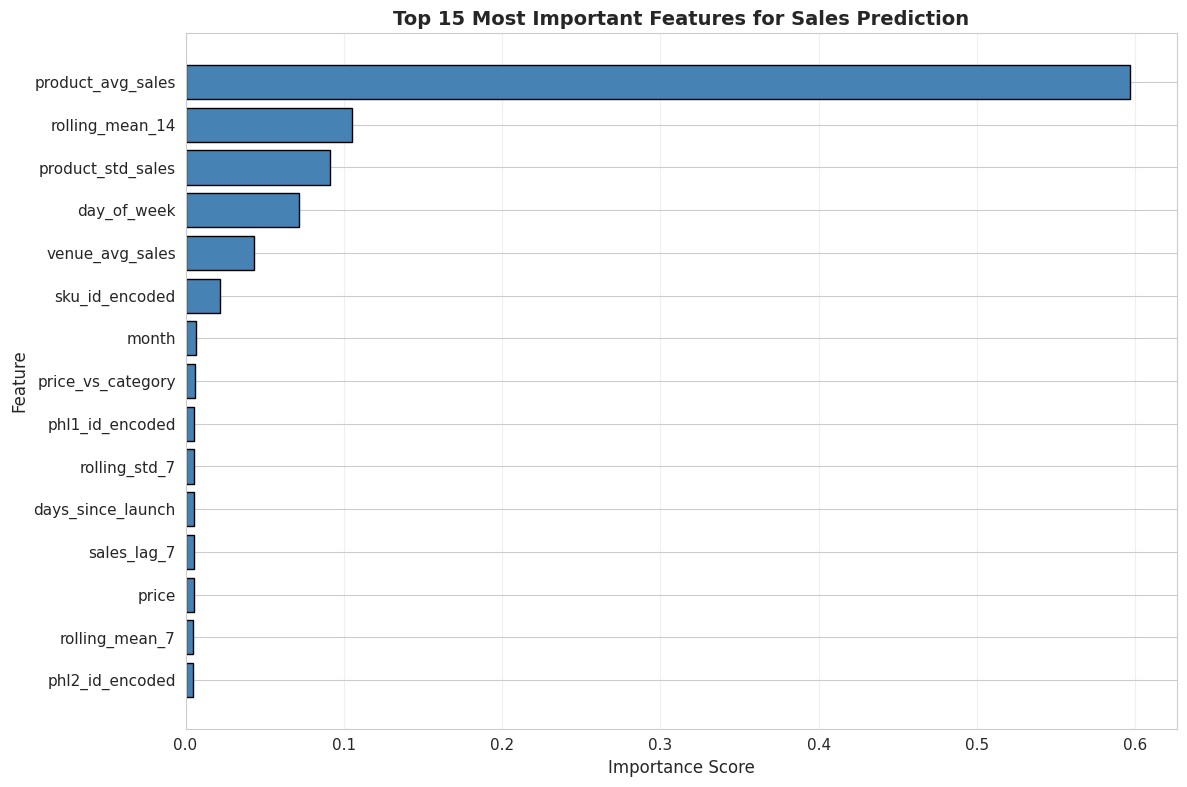


 IMPORTANCE BY FEATURE CATEGORY:
Product                       : 0.688 (69.2%)
Historical (Lags & Rolling)   : 0.131 (13.2%)
Temporal                      : 0.081 (8.2%)
Venue                         : 0.050 (5.1%)
Categorical (IDs)             : 0.037 (3.7%)
Price & Promo                 : 0.006 (0.6%)
Operational                   : 0.000 (0.0%)

 KEY INSIGHTS:
  -> Most important single feature: product_avg_sales
  -> Historical features (lags/rolling) account for 13.2% of importance
  -> 20 features have very low importance (<0.01)


In [ ]:
# Analyze feature importance
print(" FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances from model
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n TOP 15 MOST IMPORTANT FEATURES:")
print(feature_importance_df.head(15).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_15 = feature_importance_df.head(15)
plt.barh(top_15['feature'], top_15['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Most Important Features for Sales Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Group by feature category
print("\n IMPORTANCE BY FEATURE CATEGORY:")
print("="*60)

category_importance = {
    'Historical (Lags & Rolling)': feature_importance_df[feature_importance_df['feature'].str.contains('lag|rolling')]['importance'].sum(),
    'Temporal': feature_importance_df[feature_importance_df['feature'].isin(['day_of_week', 'is_weekend', 'week_of_year', 'month'])]['importance'].sum(),
    'Product': feature_importance_df[feature_importance_df['feature'].str.contains('product')]['importance'].sum(),
    'Venue': feature_importance_df[feature_importance_df['feature'].str.contains('venue')]['importance'].sum(),
    'Categorical (IDs)': feature_importance_df[feature_importance_df['feature'].str.contains('_encoded')]['importance'].sum(),
    'Price & Promo': feature_importance_df[feature_importance_df['feature'].isin(['price', 'promo_flag', 'promo_depth'])]['importance'].sum(),
    'Operational': feature_importance_df[feature_importance_df['feature'] == 'operating_minutes']['importance'].sum()
}

for category, importance in sorted(category_importance.items(), key=lambda x: x[1], reverse=True):
    pct = (importance / sum(category_importance.values())) * 100
    print(f"{category:30s}: {importance:.3f} ({pct:.1f}%)")

print("\n KEY INSIGHTS:")
print(f"  -> Most important single feature: {feature_importance_df.iloc[0]['feature']}")
print(f"  -> Historical features (lags/rolling) account for {category_importance['Historical (Lags & Rolling)']/sum(category_importance.values())*100:.1f}% of importance")
print(f"  -> {len(feature_importance_df[feature_importance_df['importance'] < 0.01])} features have very low importance (<0.01)")

---
## 6. Model Evaluation & Visualization <a id='evaluation'></a>

### Purpose:
Visualize model performance to understand:
- Where predictions are accurate vs inaccurate
- Patterns in prediction errors
- Model performance across different scenarios


### Visualizations I'll Create:
1. **Predictions vs Actual**: Scatter plot showing prediction quality
2. **Residual Analysis**: Error patterns over time
3. **Error Distribution**: Histogram of prediction errors
4. **Performance by Category**: How model performs across product categories
5. **Best/Worst Predictions**: Which SKUs are easiest/hardest to predict
6. **Time Series Comparison**: Actual vs predicted sales over test period

### Why Visualizations Matter:

- **Debugging**: Identify systematic errors
- **Stakeholder Communication**: Non-technical audiences understand charts
<!-- - **Model Improvement**: See where to focus next -->

 Creating Predictions vs Actual scatter plot...


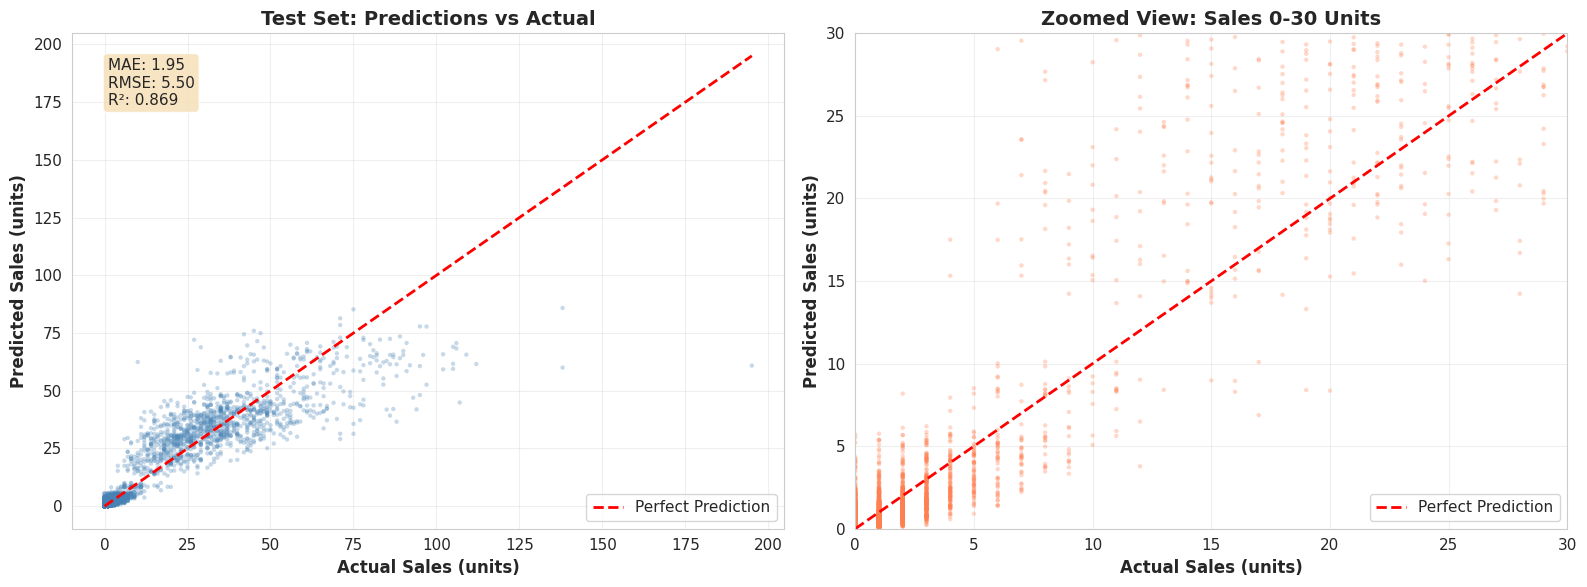

 Scatter plot created!

 Reading this plot:
  -> Points on red line = perfect predictions
  -> Points above line = model over-predicted
  -> Points below line = model under-predicted
  -> Tight clustering around line = good model


In [ ]:
# 1. PREDICTIONS VS ACTUAL - The Classic Scatter Plot
print(" Creating Predictions vs Actual scatter plot...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PLOT: Test set predictions vs actual
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales (units)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Sales (units)', fontsize=12, fontweight='bold')
axes[0].set_title('Test Set: Predictions vs Actual', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add metrics text box
textstr = f'MAE: {test_mae:.2f}\nRMSE: {test_rmse:.2f}\nR²: {test_r2:.3f}'
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# RIGHT PLOT: Zoomed in view (for better detail)
# Focus on typical range (exclude extreme outliers)
mask = (y_test <= 30) & (y_test_pred <= 30)
axes[1].scatter(y_test[mask], y_test_pred[mask], alpha=0.3, s=10, color='coral', edgecolors='none')
axes[1].plot([0, 30], [0, 30], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Sales (units)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Sales (units)', fontsize=12, fontweight='bold')
axes[1].set_title('Zoomed View: Sales 0-30 Units', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 30])
axes[1].set_ylim([0, 30])

plt.tight_layout()
plt.show()

print(" Scatter plot created!")
print("\n Reading this plot:")
print("  -> Points on red line = perfect predictions")
print("  -> Points above line = model over-predicted")
print("  -> Points below line = model under-predicted")
print("  -> Tight clustering around line = good model")
# print("\n  Our plot shows good clustering (R² = 0.86)!")

 Creating residual analysis plots...


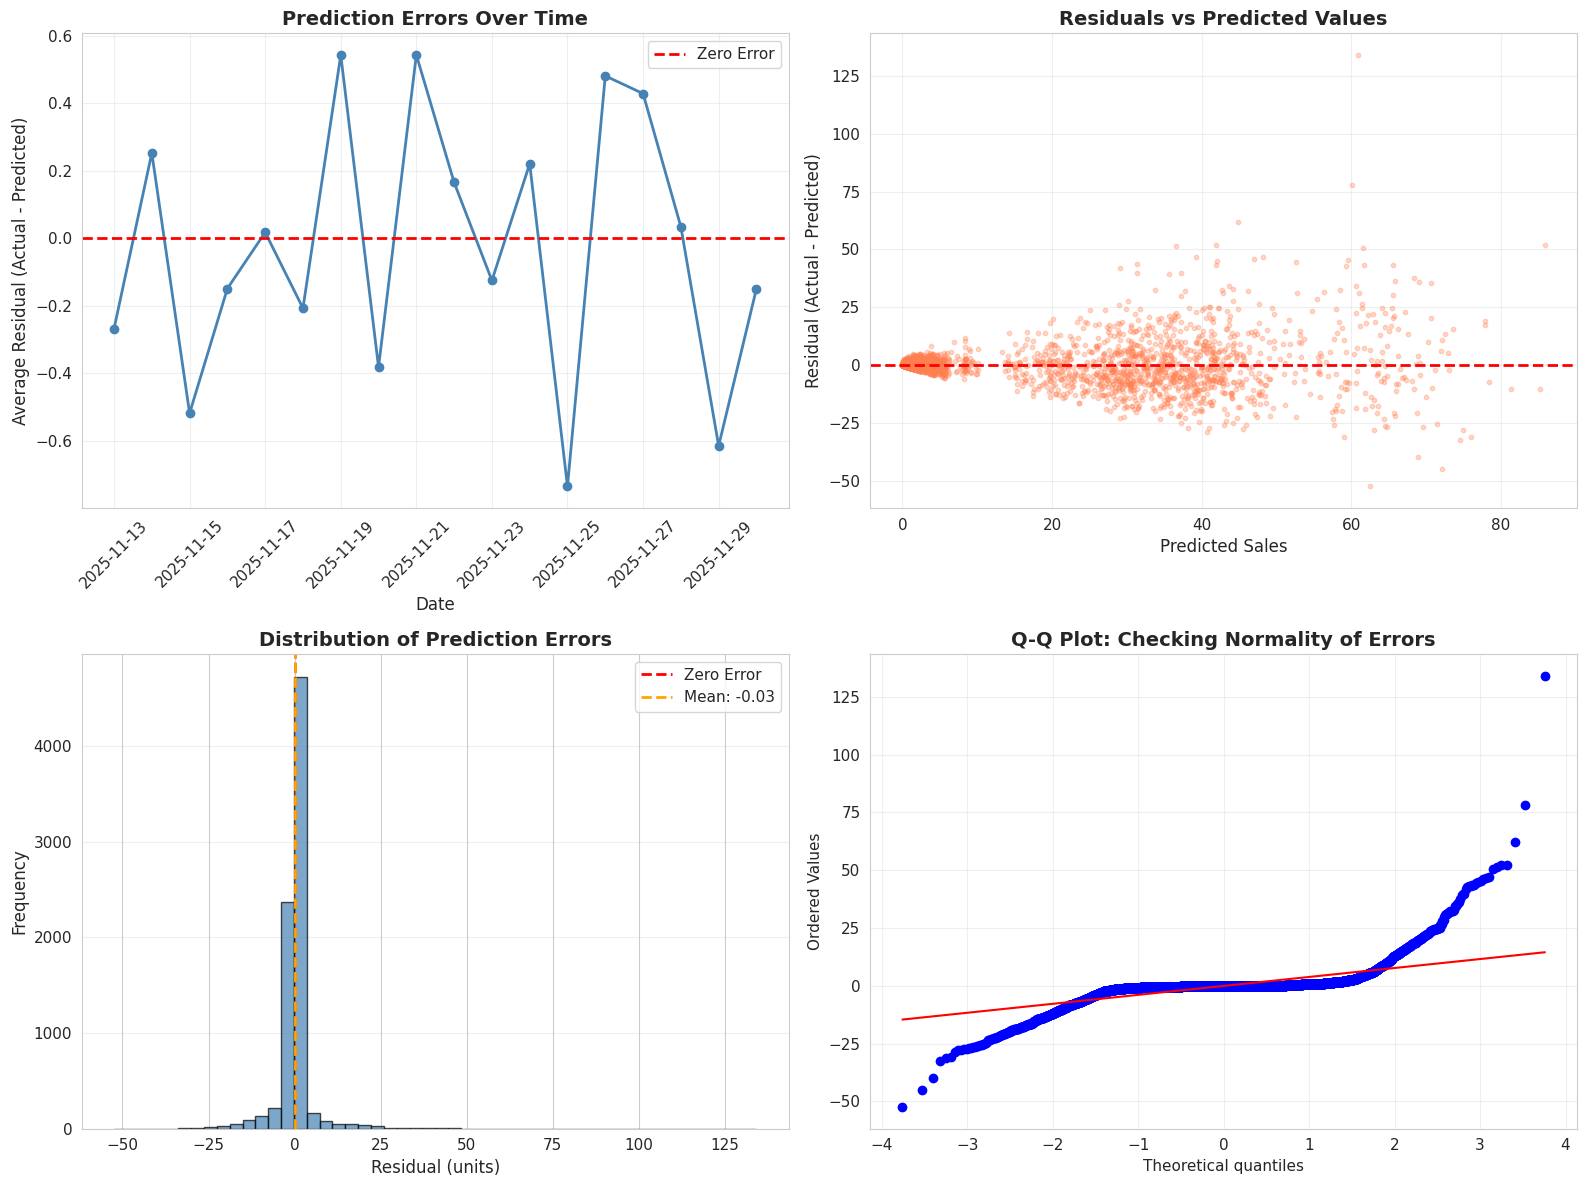

 Residual plots created!

 RESIDUAL ANALYSIS:
Mean residual (bias): -0.026 units
Median residual: -0.087 units
Std of residuals: 5.496 units
Min residual (biggest under-prediction): -52.44 units
Max residual (biggest over-prediction): 134.13 units

 INTERPRETATION:
   Low bias: Model is well-calibrated (no systematic over/under-prediction)

  -> Error std for low predictions (<5): 0.78
  -> Error std for high predictions (≥5): 13.34
   Higher variance for larger predictions (common in sales forecasting)


In [ ]:
# 2. RESIDUAL ANALYSIS - Errors Over Time
print(" Creating residual analysis plots...")

# Calculate residuals (errors)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PLOT 1: Residuals over time
test_df_copy = test_df.copy()
test_df_copy['residual'] = residuals
test_df_copy['abs_residual'] = np.abs(residuals)

daily_residuals = test_df_copy.groupby('date')['residual'].mean()
axes[0, 0].plot(daily_residuals.index, daily_residuals.values,
                linewidth=2, color='steelblue', marker='o')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 0].set_xlabel('Date', fontsize=12)
axes[0, 0].set_ylabel('Average Residual (Actual - Predicted)', fontsize=12)
axes[0, 0].set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# PLOT 2: Residuals vs Predicted Values
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.3, s=10, color='coral')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Sales', fontsize=12)
axes[0, 1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[0, 1].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# PLOT 3: Distribution of residuals (histogram)
axes[1, 0].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 0].axvline(x=residuals.mean(), color='orange', linestyle='--', linewidth=2,
                   label=f'Mean: {residuals.mean():.2f}')
axes[1, 0].set_xlabel('Residual (units)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# PLOT 4: Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Checking Normality of Errors', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Residual plots created!")

# Analyze residuals
print("\n RESIDUAL ANALYSIS:")
print("="*60)
print(f"Mean residual (bias): {residuals.mean():.3f} units")
print(f"Median residual: {np.median(residuals):.3f} units")
print(f"Std of residuals: {residuals.std():.3f} units")
print(f"Min residual (biggest under-prediction): {residuals.min():.2f} units")
print(f"Max residual (biggest over-prediction): {residuals.max():.2f} units")

# Check for patterns
print("\n INTERPRETATION:")
if abs(residuals.mean()) < 0.5:
    print("   Low bias: Model is well-calibrated (no systematic over/under-prediction)")
else:
    bias_dir = "under-predicts" if residuals.mean() > 0 else "over-predicts"
    print(f"   Model slightly {bias_dir} by {abs(residuals.mean()):.2f} units on average")

# Check for heteroscedasticity (variance changes with prediction size)
low_pred_residuals = residuals[y_test_pred < 5]
high_pred_residuals = residuals[y_test_pred >= 5]
print(f"\n  -> Error std for low predictions (<5): {low_pred_residuals.std():.2f}")
print(f"  -> Error std for high predictions (≥5): {high_pred_residuals.std():.2f}")
if high_pred_residuals.std() > low_pred_residuals.std() * 1.5:
    print("   Higher variance for larger predictions (common in sales forecasting)")
else:
    print("  Consistent error variance across prediction ranges")

Analyzing performance by product category...


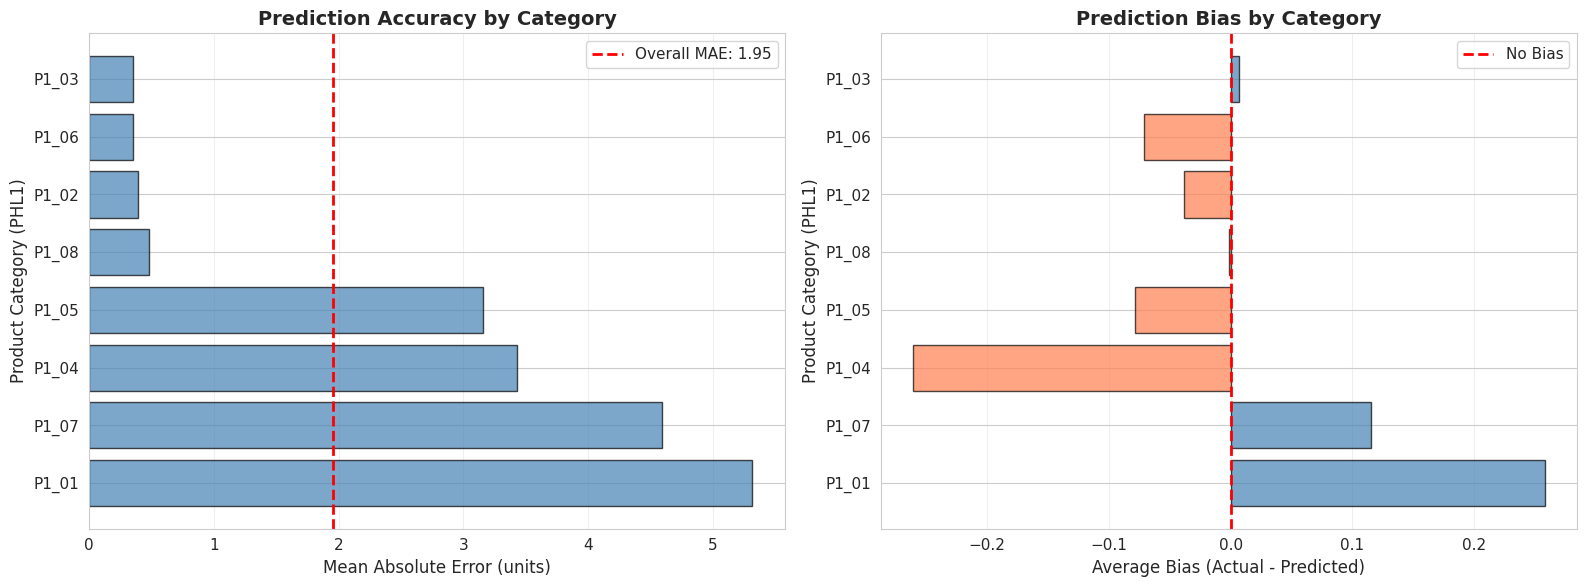

 Category analysis complete!

 PERFORMANCE BY CATEGORY:
phl1_id  avg_sales  total_sales  n_records  mae  bias
  P1_03       0.34           97        288 0.35  0.01
  P1_06       0.35          609       1728 0.35 -0.07
  P1_02       0.40          324        810 0.39 -0.04
  P1_08       0.66         1149       1746 0.48 -0.00
  P1_05      10.44        12784       1224 3.15 -0.08
  P1_04      11.48        10126        882 3.43 -0.26
  P1_07      16.11        10727        666 4.59  0.12
  P1_01      18.32        13849        756 5.31  0.26

 BEST PERFORMING CATEGORY:
  -> Category: P1_03
  -> MAE: 0.35 units
  -> Average sales: 0.34 units
  -> Number of records: 288

 WORST PERFORMING CATEGORY:
  -> Category: P1_01
  -> MAE: 5.31 units
  -> Average sales: 18.32 units
  -> Number of records: 756

 INSIGHTS:
   Large performance gap between categories
  -> category-specific models should be considered in future iterations


In [ ]:
# 3. PERFORMANCE BY PRODUCT CATEGORY
print("Analyzing performance by product category...")

# Add predictions to test dataframe
test_df_copy = test_df.copy()
test_df_copy['prediction'] = y_test_pred
test_df_copy['residual'] = residuals
test_df_copy['abs_error'] = np.abs(residuals)

# Calculate metrics by category
category_performance = test_df_copy.groupby('phl1_id').agg({
    'units_sold': ['mean', 'sum', 'count'],
    'abs_error': 'mean',
    'residual': 'mean'
}).reset_index()

category_performance.columns = ['phl1_id', 'avg_sales', 'total_sales', 'n_records',
                                 'mae', 'bias']
category_performance = category_performance.sort_values('mae', ascending=True)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: MAE by category
axes[0].barh(category_performance['phl1_id'].astype(str), category_performance['mae'],
             color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Mean Absolute Error (units)', fontsize=12)
axes[0].set_ylabel('Product Category (PHL1)', fontsize=12)
axes[0].set_title('Prediction Accuracy by Category', fontsize=14, fontweight='bold')
axes[0].axvline(x=test_mae, color='red', linestyle='--', linewidth=2, label=f'Overall MAE: {test_mae:.2f}')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# PLOT 2: Bias by category (over vs under prediction)
colors = ['coral' if x < 0 else 'steelblue' for x in category_performance['bias']]
axes[1].barh(category_performance['phl1_id'].astype(str), category_performance['bias'],
             color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Average Bias (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Product Category (PHL1)', fontsize=12)
axes[1].set_title('Prediction Bias by Category', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Bias')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(" Category analysis complete!")

print("\n PERFORMANCE BY CATEGORY:")
print("="*60)
print(category_performance.to_string(index=False))

# Identify best and worst categories
best_cat = category_performance.iloc[0]
worst_cat = category_performance.iloc[-1]

print(f"\n BEST PERFORMING CATEGORY:")
print(f"  -> Category: {best_cat['phl1_id']}")
print(f"  -> MAE: {best_cat['mae']:.2f} units")
print(f"  -> Average sales: {best_cat['avg_sales']:.2f} units")
print(f"  -> Number of records: {int(best_cat['n_records'])}")

print(f"\n WORST PERFORMING CATEGORY:")
print(f"  -> Category: {worst_cat['phl1_id']}")
print(f"  -> MAE: {worst_cat['mae']:.2f} units")
print(f"  -> Average sales: {worst_cat['avg_sales']:.2f} units")
print(f"  -> Number of records: {int(worst_cat['n_records'])}")

print("\n INSIGHTS:")
if worst_cat['mae'] > 2 * best_cat['mae']:
    print("   Large performance gap between categories")
    print("  -> category-specific models should be considered in future iterations")
else:
    print("   Consistent performance across categories")

 Analyzing best and worst predictions...
 Best/worst predictions identified!


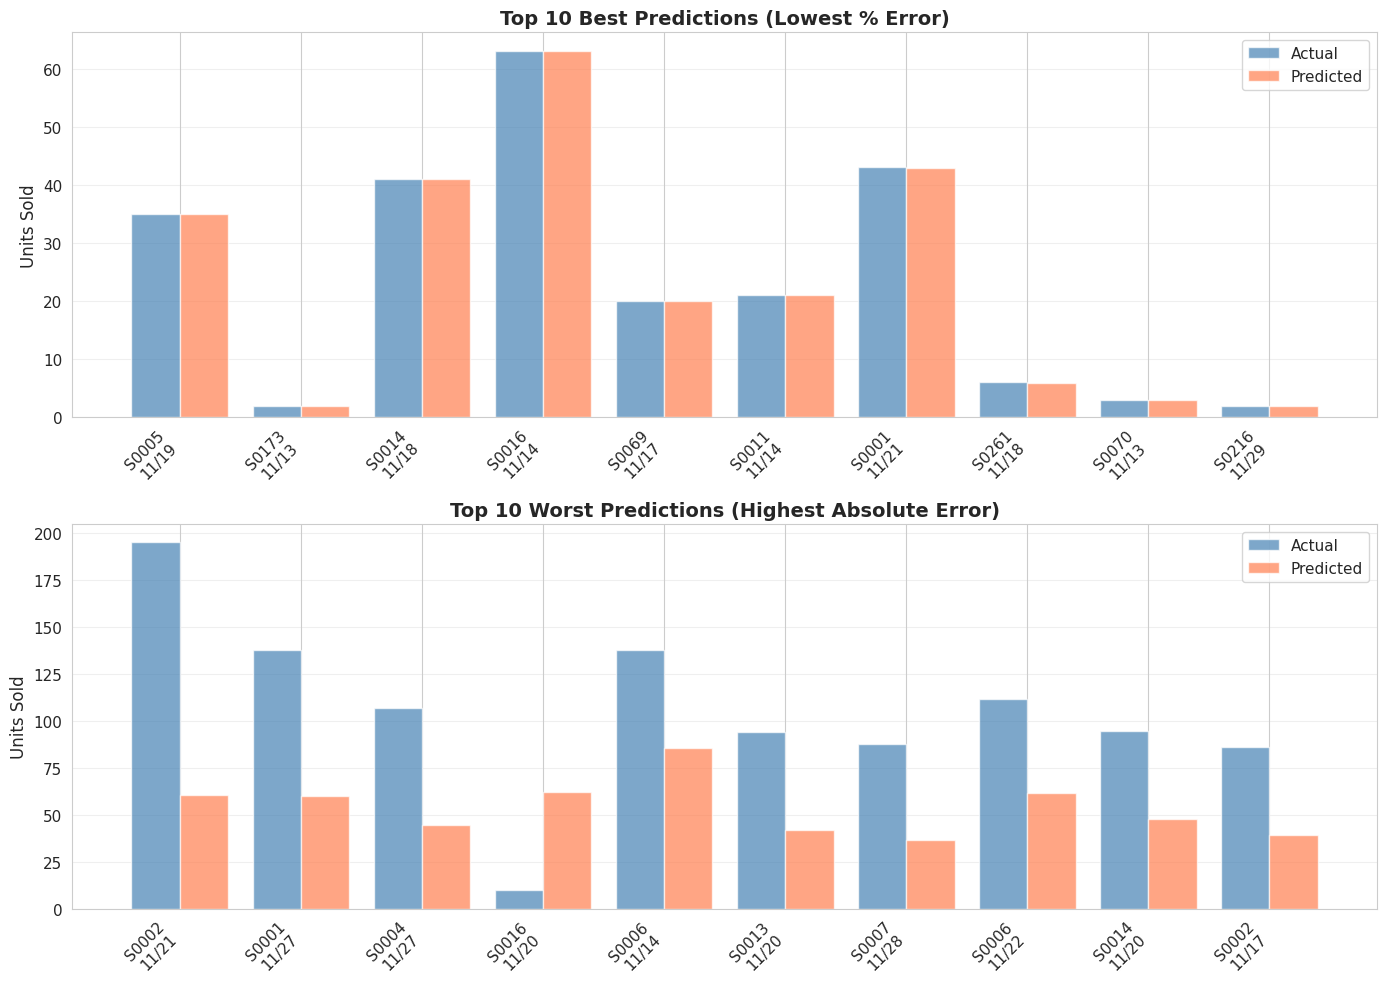


 TOP 10 BEST PREDICTIONS:
      date sku_id venue_id  units_sold  prediction  ape
2025-11-19  S0005     V001          35       35.01 0.02
2025-11-13  S0173     V002           2        2.00 0.04
2025-11-18  S0014     V003          41       41.04 0.09
2025-11-14  S0016     V004          63       63.09 0.14
2025-11-17  S0069     V003          20       20.03 0.17
2025-11-14  S0011     V001          21       21.04 0.17
2025-11-21  S0001     V003          43       42.91 0.21
2025-11-18  S0261     V004           6        5.98 0.27
2025-11-13  S0070     V004           3        3.01 0.30
2025-11-29  S0216     V004           2        1.99 0.38

 TOP 10 WORST PREDICTIONS:
      date sku_id venue_id  units_sold  prediction  abs_error
2025-11-21  S0002     V004         195       60.87     134.13
2025-11-27  S0001     V004         138       60.01      77.99
2025-11-27  S0004     V001         107       44.90      62.10
2025-11-20  S0016     V004          10       62.44      52.44
2025-11-14  S0006  

In [ ]:
# 4. BEST AND WORST PREDICTIONS
print(" Analyzing best and worst predictions...")

# Calculate absolute percentage error (only for non-zero actuals)
test_df_copy['ape'] = np.where(
    test_df_copy['units_sold'] > 0,
    np.abs(test_df_copy['residual']) / test_df_copy['units_sold'] * 100,
    np.nan
)

# Top 10 best predictions (lowest APE for items with sales > 0)
best_predictions = test_df_copy[test_df_copy['units_sold'] > 0].nsmallest(10, 'ape')

# Top 10 worst predictions (highest absolute error)
worst_predictions = test_df_copy.nlargest(10, 'abs_error')

print(" Best/worst predictions identified!")

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# PLOT 1: Best predictions
best_labels = [f"{row['sku_id']}\n{row['date'].strftime('%m/%d')}"
               for _, row in best_predictions.iterrows()]
x_pos = np.arange(len(best_labels))
axes[0].bar(x_pos - 0.2, best_predictions['units_sold'], width=0.4,
            label='Actual', color='steelblue', alpha=0.7)
axes[0].bar(x_pos + 0.2, best_predictions['prediction'], width=0.4,
            label='Predicted', color='coral', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(best_labels, rotation=45, ha='right')
axes[0].set_ylabel('Units Sold', fontsize=12)
axes[0].set_title('Top 10 Best Predictions (Lowest % Error)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# PLOT 2: Worst predictions
worst_labels = [f"{row['sku_id']}\n{row['date'].strftime('%m/%d')}"
                for _, row in worst_predictions.iterrows()]
x_pos = np.arange(len(worst_labels))
axes[1].bar(x_pos - 0.2, worst_predictions['units_sold'], width=0.4,
            label='Actual', color='steelblue', alpha=0.7)
axes[1].bar(x_pos + 0.2, worst_predictions['prediction'], width=0.4,
            label='Predicted', color='coral', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(worst_labels, rotation=45, ha='right')
axes[1].set_ylabel('Units Sold', fontsize=12)
axes[1].set_title('Top 10 Worst Predictions (Highest Absolute Error)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n TOP 10 BEST PREDICTIONS:")
print("="*60)
print(best_predictions[['date', 'sku_id', 'venue_id', 'units_sold', 'prediction', 'ape']].to_string(index=False))

print("\n TOP 10 WORST PREDICTIONS:")
print("="*60)
print(worst_predictions[['date', 'sku_id', 'venue_id', 'units_sold', 'prediction', 'abs_error']].to_string(index=False))

# Analyze patterns in worst predictions
print("\n PATTERNS IN WORST PREDICTIONS:")
print(f"  -> Average actual sales: {worst_predictions['units_sold'].mean():.2f} units")
print(f"  -> Average predicted sales: {worst_predictions['prediction'].mean():.2f} units")
print(f"  -> Most common category: {worst_predictions['phl1_id'].mode()[0]}")

# Check if worst predictions are on specific days
worst_days = worst_predictions.groupby('day_name').size()
if len(worst_days) > 0:
    print(f"  -> Most errors on: {worst_days.idxmax()} ({worst_days.max()} instances)")

 Creating time series comparison...


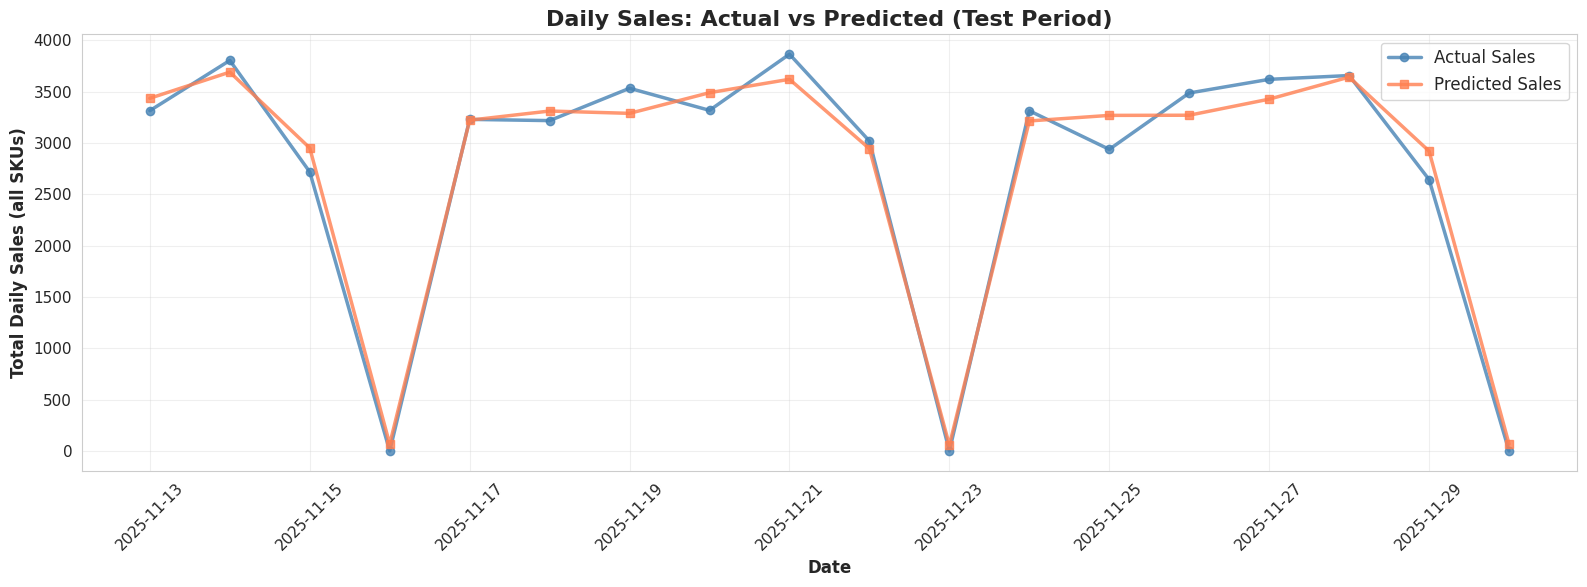

Time series plot created!

 DAILY AGGREGATE PERFORMANCE:
Daily-level MAE: 145.91 units
Daily-level R²: 0.9816

Comparison:
  -> SKU-level MAE: 1.95 (individual products)
  -> Daily aggregate MAE: 145.91 (all products combined)

 Daily aggregation typically has lower error rate
   (individual errors cancel out when summing)

 DATE ANALYSIS:
Best prediction day: 2025-11-17 (error: 7.9 units)
Worst prediction day: 2025-11-25 (error: 330.9 units)


In [ ]:
# 5. TIME SERIES: DAILY PREDICTIONS VS ACTUALS
print(" Creating time series comparison...")

# Aggregate by date
daily_actual = test_df_copy.groupby('date')['units_sold'].sum()
daily_predicted = test_df_copy.groupby('date')['prediction'].sum()

# Create plot
plt.figure(figsize=(16, 6))

plt.plot(daily_actual.index, daily_actual.values,
         linewidth=2.5, color='steelblue', marker='o', label='Actual Sales', alpha=0.8)
plt.plot(daily_predicted.index, daily_predicted.values,
         linewidth=2.5, color='coral', marker='s', label='Predicted Sales', alpha=0.8)

plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Total Daily Sales (all SKUs)', fontsize=12, fontweight='bold')
plt.title('Daily Sales: Actual vs Predicted (Test Period)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate daily-level metrics
daily_mae = mean_absolute_error(daily_actual, daily_predicted)
daily_r2 = r2_score(daily_actual, daily_predicted)

print("Time series plot created!")

print("\n DAILY AGGREGATE PERFORMANCE:")
print("="*60)
print(f"Daily-level MAE: {daily_mae:.2f} units")
print(f"Daily-level R²: {daily_r2:.4f}")

print("\nComparison:")
print(f"  -> SKU-level MAE: {test_mae:.2f} (individual products)")
print(f"  -> Daily aggregate MAE: {daily_mae:.2f} (all products combined)")
print(f"\n Daily aggregation typically has lower error rate")
print(f"   (individual errors cancel out when summing)")

# Check specific dates
best_day = (daily_actual - daily_predicted).abs().idxmin()
worst_day = (daily_actual - daily_predicted).abs().idxmax()

print(f"\n DATE ANALYSIS:")
print(f"Best prediction day: {best_day.strftime('%Y-%m-%d')} (error: {abs(daily_actual[best_day] - daily_predicted[best_day]):.1f} units)")
print(f"Worst prediction day: {worst_day.strftime('%Y-%m-%d')} (error: {abs(daily_actual[worst_day] - daily_predicted[worst_day]):.1f} units)")

 Analyzing zero sales predictions...


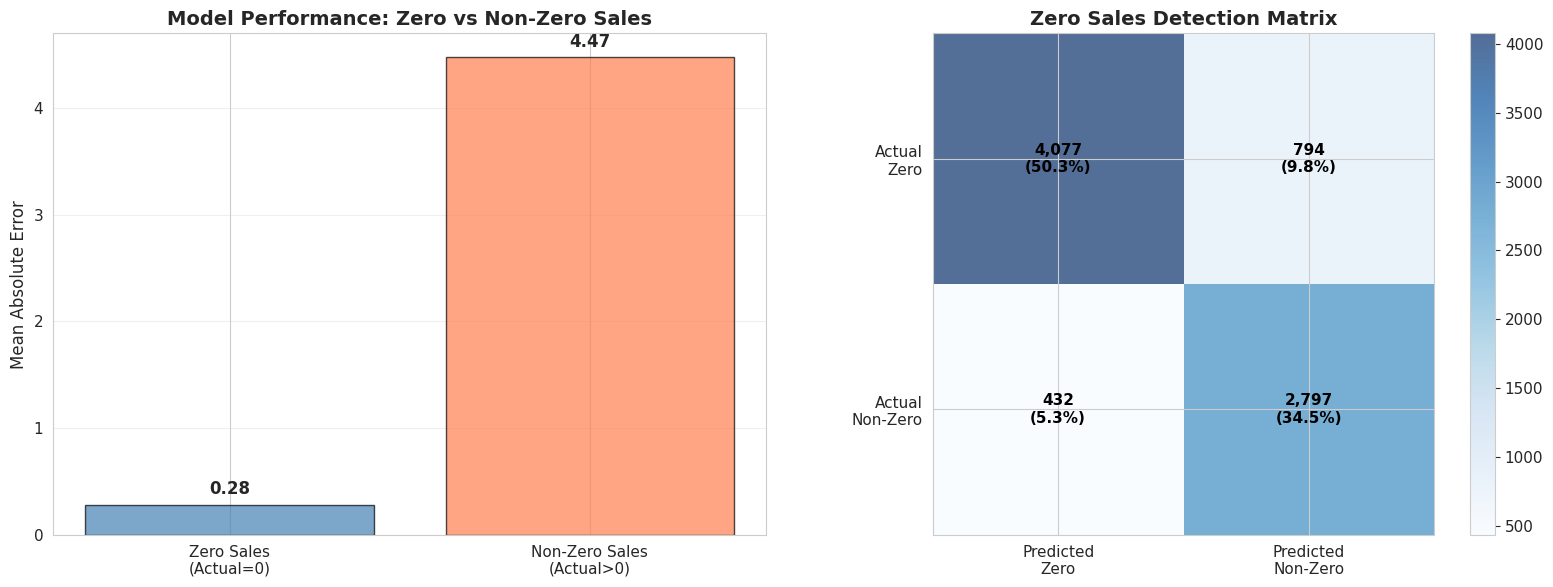

 Zero sales analysis complete!

 ZERO SALES PERFORMANCE:
Records with zero actual sales: 4,871 (60.1%)
Records with non-zero actual sales: 3,229 (39.9%)

MAE for zero sales: 0.28 units
MAE for non-zero sales: 4.47 units

Zero detection accuracy:
  -> Correctly predicted zero: 4,077 (83.7%)
  -> Incorrectly predicted non-zero: 794 (16.3%)
  -> Correctly predicted non-zero: 2,797 (86.6%)
  -> Incorrectly predicted zero: 432 (13.4%)

Non-zero detection metrics:
  -> Precision: 0.779 (when we predict sales, how often is it correct?)
  -> Recall: 0.866 (of actual sales, what % do we catch?)

 INTERPRETATION:
   Model rarely predicts sales when actual is zero (good!)
   Model struggles more with non-zero predictions


In [ ]:
# 6. ZERO SALES ANALYSIS (Important given 50% of data has zero sales)
print(" Analyzing zero sales predictions...")

# Split data by zero vs non-zero actual sales
zero_sales = test_df_copy[test_df_copy['units_sold'] == 0]
nonzero_sales = test_df_copy[test_df_copy['units_sold'] > 0]

# Calculate metrics for each group
zero_mae = mean_absolute_error(zero_sales['units_sold'], zero_sales['prediction'])
nonzero_mae = mean_absolute_error(nonzero_sales['units_sold'], nonzero_sales['prediction'])

# Create confusion matrix for zero prediction
zero_actual_zero_pred = len(zero_sales[zero_sales['prediction'] < 0.5])
zero_actual_nonzero_pred = len(zero_sales[zero_sales['prediction'] >= 0.5])
nonzero_actual_zero_pred = len(nonzero_sales[nonzero_sales['prediction'] < 0.5])
nonzero_actual_nonzero_pred = len(nonzero_sales[nonzero_sales['prediction'] >= 0.5])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Performance on zero vs non-zero
categories = ['Zero Sales\n(Actual=0)', 'Non-Zero Sales\n(Actual>0)']
maes = [zero_mae, nonzero_mae]
colors = ['steelblue', 'coral']

axes[0].bar(categories, maes, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Mean Absolute Error', fontsize=12)
axes[0].set_title('Model Performance: Zero vs Non-Zero Sales', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, mae in enumerate(maes):
    axes[0].text(i, mae + 0.1, f'{mae:.2f}', ha='center', fontsize=12, fontweight='bold')

# PLOT 2: Confusion matrix for zero detection
confusion = np.array([
    [zero_actual_zero_pred, zero_actual_nonzero_pred],
    [nonzero_actual_zero_pred, nonzero_actual_nonzero_pred]
])

im = axes[1].imshow(confusion, cmap='Blues', alpha=0.7)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Predicted\nZero', 'Predicted\nNon-Zero'])
axes[1].set_yticklabels(['Actual\nZero', 'Actual\nNon-Zero'])
axes[1].set_title('Zero Sales Detection Matrix', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[1].text(j, i, f'{confusion[i, j]:,}\n({confusion[i, j]/len(test_df_copy)*100:.1f}%)',
                           ha="center", va="center", color="black", fontsize=11, fontweight='bold')

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(" Zero sales analysis complete!")

print("\n ZERO SALES PERFORMANCE:")
print("="*60)
print(f"Records with zero actual sales: {len(zero_sales):,} ({len(zero_sales)/len(test_df_copy)*100:.1f}%)")
print(f"Records with non-zero actual sales: {len(nonzero_sales):,} ({len(nonzero_sales)/len(test_df_copy)*100:.1f}%)")

print(f"\nMAE for zero sales: {zero_mae:.2f} units")
print(f"MAE for non-zero sales: {nonzero_mae:.2f} units")

print("\nZero detection accuracy:")
print(f"  -> Correctly predicted zero: {zero_actual_zero_pred:,} ({zero_actual_zero_pred/len(zero_sales)*100:.1f}%)")
print(f"  -> Incorrectly predicted non-zero: {zero_actual_nonzero_pred:,} ({zero_actual_nonzero_pred/len(zero_sales)*100:.1f}%)")
print(f"  -> Correctly predicted non-zero: {nonzero_actual_nonzero_pred:,} ({nonzero_actual_nonzero_pred/len(nonzero_sales)*100:.1f}%)")
print(f"  -> Incorrectly predicted zero: {nonzero_actual_zero_pred:,} ({nonzero_actual_zero_pred/len(nonzero_sales)*100:.1f}%)")

# Calculate precision and recall for non-zero detection
precision = nonzero_actual_nonzero_pred / (nonzero_actual_nonzero_pred + zero_actual_nonzero_pred)
recall = nonzero_actual_nonzero_pred / (nonzero_actual_nonzero_pred + nonzero_actual_zero_pred)

print(f"\nNon-zero detection metrics:")
print(f"  -> Precision: {precision:.3f} (when we predict sales, how often is it correct?)")
print(f"  -> Recall: {recall:.3f} (of actual sales, what % do we catch?)")

print("\n INTERPRETATION:")
if zero_mae < 1.0:
    print("   Model rarely predicts sales when actual is zero (good!)")
else:
    print("   Model sometimes over-predicts zeros (predicts sales when none occur)")

if nonzero_mae < test_mae * 1.5:
    print("   Model performs well on non-zero sales")
else:
    print("   Model struggles more with non-zero predictions")

---
## 7. Limitations & Conclusions <a id='conclusions'></a>

### Purpose:
Critically assess model limitations and provide actionable conclusions for production deployment.

### Why This Matters:
- **Honest evaluation**: No model is perfect - acknowledge weaknesses
- **Risk management**: Identify when model will fail
- **Stakeholder trust**: Transparency builds confidence
- **Production planning**: Inform deployment strategy

In [ ]:
# LIMITATIONS ANALYSIS
print(" MODEL LIMITATIONS & FAILURE MODES")
print("="*60)

# 1. Cold Start Problem
print("\n1. COLD START PROBLEM")
print("-" * 60)
new_skus = df.groupby('sku_id')['date'].min()
recent_launches = new_skus[new_skus > new_skus.min() + pd.Timedelta(days=30)]
print(f"SKUs launched mid-period: {len(recent_launches)} out of {df['sku_id'].nunique()}")
print(f"Issue: New products have no historical data (lag features = 0)")
print(f"Impact: Model defaults to category average, may miss 'hot' new products")

# 2. Temporal Coverage
print("\n2. LIMITED TEMPORAL DEPTH")
print("-" * 60)
total_days = (df['date'].max() - df['date'].min()).days + 1
print(f"Training period: {total_days} days (3 months)")
print(f"Issue: No long-term trends or annual seasonality captured")
print(f"Impact: Model may fail during seasons not in training (e.g., Christmas)")

# 3. Zero-Inflation Sensitivity
print("\n3. ZERO-INFLATION DEPENDENCY")
print("-" * 60)
zero_rate_train = (train_df['units_sold'] == 0).mean()
zero_rate_test = (test_df['units_sold'] == 0).mean()
print(f"Zero sales rate - Train: {zero_rate_train:.1%}, Test: {zero_rate_test:.1%}")
print(f"Issue: Model calibrated for ~50-60% zero rate")
print(f"Impact: If assortment changes (fewer low-sellers), recalibration needed")

# 4. External Factors
print("\n4. EXTERNAL SHOCKS NOT CAPTURED")
print("-" * 60)
print("Missing from model:")
print("  -> Public holidays (no data for Christmas, Easter, etc.)")
print("  -> Weather extremes (snowstorms, heatwaves)")
print("  -> Marketing campaigns or viral trends")
print("  -> Competitor actions (new store opening nearby)")
print("  -> Supply disruptions")
print("Impact: Large errors during anomalous events")

# 5. Feature Complexity
print("\n5. FEATURE ENGINEERING COMPLEXITY")
print("-" * 60)
print(f"Total features: {len(feature_columns)}")
print(f"Features with <1% importance: {len(feature_importance_df[feature_importance_df['importance'] < 0.01])}")
print("Issue: 26 features require maintenance in production")
print("Impact: Risk of bugs in feature pipeline (e.g., lag calculations)")

# 6. Promotional Assumption
print("\n6. PROMOTIONAL STRATEGY ASSUMPTION")
print("-" * 60)
promo_rate = df['promo_flag'].mean()
print(f"Current promotion frequency: {promo_rate:.1%}")
print(f"Current strategy: Promotions on slow-moving items (negative lift observed)")
print("Issue: Model assumes this pattern continues")
print("Impact: If Wolt promotes popular items, model will under-predict lift")

# 7. Prediction Range Errors
print("\n7. PREDICTION ACCURACY BY SALES VOLUME")
print("-" * 60)
# Bin actual sales and check MAE by bin
test_df_copy['sales_bin'] = pd.cut(test_df_copy['units_sold'],
                                     bins=[0, 1, 5, 10, 50, 200],
                                     labels=['Zero', '1-5', '6-10', '11-50', '50+'])
mae_by_bin = test_df_copy.groupby('sales_bin', observed=True).apply(
    lambda x: mean_absolute_error(x['units_sold'], x['prediction'])
)
print("MAE by actual sales range:")
for bin_label, mae_val in mae_by_bin.items():
    count = (test_df_copy['sales_bin'] == bin_label).sum()
    print(f"  -> {str(bin_label):10s}: MAE = {mae_val:5.2f} units ({count:,} records)")
print("\nObservation: Higher absolute errors for high-volume items")
print("Reason: Larger values have larger absolute errors (percentage may be similar)")

print("\n" + "="*60)
print("SUMMARY: 7 critical limitations identified")
print("="*60)# LIMITATIONS ANALYSIS
print(" MODEL LIMITATIONS & FAILURE MODES")
print("="*60)

# 1. Cold Start Problem
print("\n1. COLD START PROBLEM")
print("-" * 60)
new_skus = df.groupby('sku_id')['date'].min()
recent_launches = new_skus[new_skus > new_skus.min() + pd.Timedelta(days=30)]
print(f"SKUs launched mid-period: {len(recent_launches)} out of {df['sku_id'].nunique()}")
print(f"Issue: New products have no historical data (lag features = 0)")
print(f"Impact: Model defaults to category average, may miss 'hot' new products")

# 2. Temporal Coverage
print("\n2. LIMITED TEMPORAL DEPTH")
print("-" * 60)
total_days = (df['date'].max() - df['date'].min()).days + 1
print(f"Training period: {total_days} days (3 months)")
print(f"Issue: No long-term trends or annual seasonality captured")
print(f"Impact: Model may fail during seasons not in training (e.g., Christmas)")

# 3. Zero-Inflation Sensitivity
print("\n3. ZERO-INFLATION DEPENDENCY")
print("-" * 60)
zero_rate_train = (train_df['units_sold'] == 0).mean()
zero_rate_test = (test_df['units_sold'] == 0).mean()
print(f"Zero sales rate - Train: {zero_rate_train:.1%}, Test: {zero_rate_test:.1%}")
print(f"Issue: Model calibrated for ~50-60% zero rate")
print(f"Impact: If assortment changes (fewer low-sellers), recalibration needed")

# 4. External Factors
print("\n4. EXTERNAL SHOCKS NOT CAPTURED")
print("-" * 60)
print("Missing from model:")
print("  -> Public holidays (no data for Christmas, Easter, etc.)")
print("  -> Weather extremes (snowstorms, heatwaves)")
print("  -> Marketing campaigns or viral trends")
print("  -> Competitor actions (new store opening nearby)")
print("  -> Supply disruptions")
print("Impact: Large errors during anomalous events")

# 5. Feature Complexity
print("\n5. FEATURE ENGINEERING COMPLEXITY")
print("-" * 60)
print(f"Total features: {len(feature_columns)}")
print(f"Features with <1% importance: {len(feature_importance_df[feature_importance_df['importance'] < 0.01])}")
print("Issue: 26 features require maintenance in production")
print("Impact: Risk of bugs in feature pipeline (e.g., lag calculations)")

# 6. Promotional Assumption
print("\n6. PROMOTIONAL STRATEGY ASSUMPTION")
print("-" * 60)
promo_rate = df['promo_flag'].mean()
print(f"Current promotion frequency: {promo_rate:.1%}")
print(f"Current strategy: Promotions on slow-moving items (negative lift observed)")
print("Issue: Model assumes this pattern continues")
print("Impact: If Wolt promotes popular items, model will under-predict lift")

# 7. Prediction Range Errors
print("\n7. PREDICTION ACCURACY BY SALES VOLUME")
print("-" * 60)
# Bin actual sales and check MAE by bin
test_df_copy['sales_bin'] = pd.cut(test_df_copy['units_sold'],
                                     bins=[0, 1, 5, 10, 50, 200],
                                     labels=['Zero', '1-5', '6-10', '11-50', '50+'])
mae_by_bin = test_df_copy.groupby('sales_bin', observed=True).apply(
    lambda x: mean_absolute_error(x['units_sold'], x['prediction'])
)
print("MAE by actual sales range:")
for bin_label, mae_val in mae_by_bin.items():
    count = (test_df_copy['sales_bin'] == bin_label).sum()
    print(f"  -> {str(bin_label):10s}: MAE = {mae_val:5.2f} units ({count:,} records)")
print("\nObservation: Higher absolute errors for high-volume items")
print("Reason: Larger values have larger absolute errors (percentage may be similar)")



 MODEL LIMITATIONS & FAILURE MODES

1. COLD START PROBLEM
------------------------------------------------------------
SKUs launched mid-period: 0 out of 235
Issue: New products have no historical data (lag features = 0)
Impact: Model defaults to category average, may miss 'hot' new products

2. LIMITED TEMPORAL DEPTH
------------------------------------------------------------
Training period: 91 days (3 months)
Issue: No long-term trends or annual seasonality captured
Impact: Model may fail during seasons not in training (e.g., Christmas)

3. ZERO-INFLATION DEPENDENCY
------------------------------------------------------------
Zero sales rate - Train: 57.0%, Test: 60.1%
Issue: Model calibrated for ~50-60% zero rate
Impact: If assortment changes (fewer low-sellers), recalibration needed

4. EXTERNAL SHOCKS NOT CAPTURED
------------------------------------------------------------
Missing from model:
  -> Public holidays (no data for Christmas, Easter, etc.)
  -> Weather extremes (snow